<a href="https://colab.research.google.com/github/ErvinCaraval/taller1_PLN/blob/main/taller1_PLN_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# POS Tagging workshop

Team members:

- Persona 1: Jean Pierre
- Persona 2: Ervin Caravali
- Persona 3:

# FASE I: PREPROCESAMIENTO DEL DATASET


In [1]:
# Instalando librerías con las versiones especificadas
!pip install torch>=2.0.0 torchvision>=0.15.0 pandas>=1.5.0 numpy>=1.23.0 scikit-learn>=1.2.0 pytorch-crf>=0.7.2 nltk>=3.8.0 matplotlib>=3.6.0 seaborn>=0.12.0 tqdm>=4.60.0 torchsummary

In [2]:
# ========== IMPORTACIONES PRINCIPALES ==========
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

# Librerías de CRF
from torchcrf import CRF

# ========== LIBRERÍAS DE DATOS Y PROCESAMIENTO ==========
import pandas as pd
import numpy as np
import nltk

# ========== LIBRERÍAS DE EVALUACIÓN ==========
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

# ========== LIBRERÍAS DE VISUALIZACIÓN ==========
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

# Configuración de visualización
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ========== CONFIGURACIÓN DE DISPOSITIVO ==========
# Activar cuDNN para acelerar entrenamiento en GPU
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True

# Seleccionar GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"\nDispositivo en uso: {device}")
print(f"PyTorch versión: {torch.__version__}")
print(f"GPU disponible en sistema: {torch.cuda.is_available()}")

# Mostrar información de GPU si existe
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")


Dispositivo en uso: cuda
PyTorch versión: 2.10.0+cu128
GPU disponible en sistema: True
GPU detectada: Tesla T4


In [3]:
# ========== CONFIGURACIÓN DE HIPERPARÁMETROS GLOBALES ==========
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
DROPOUT = 0.3

print(f"\nParametros configurados para el modelo:")
print(f"  - Embedding Dimension: {EMBEDDING_DIM}")
print(f"  - Hidden Dimension: {HIDDEN_DIM}")
print(f"  - Dropout: {DROPOUT}")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Epochs: {EPOCHS}")


Parametros configurados para el modelo:
  - Embedding Dimension: 100
  - Hidden Dimension: 128
  - Dropout: 0.3
  - Learning Rate: 0.001
  - Epochs: 50


In [4]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# ========== RUTAS DE DATOS ========== #
# Actualiza estas rutas para que apunten a la ubicación de tus datos en Google Drive
# Asegúrate de que la estructura de carpetas dentro de 'My Drive' coincida
BASE_DIR_DRIVE = '/content/drive/My Drive/npl/data'
ANCORA_DIR = os.path.join(BASE_DIR_DRIVE, 'ancora')
CONLL_DIR = os.path.join(BASE_DIR_DRIVE, 'conll2002')

print("Verificando estructura de datos...")
print(f"\nDirectorio Ancora: {ANCORA_DIR}")
print(f"   Archivos: {os.listdir(ANCORA_DIR) if os.path.exists(ANCORA_DIR) else 'NO EXISTE'}")

print(f"\nDirectorio CoNLL2002: {CONLL_DIR}")
print(f"   Archivos: {os.listdir(CONLL_DIR) if os.path.exists(CONLL_DIR) else 'NO EXISTE'}")

Mounted at /content/drive
Verificando estructura de datos...

Directorio Ancora: /content/drive/My Drive/npl/data/ancora
   Archivos: ['ancora_corpus_pos.csv', 'ancora_val.csv', 'ancora_train.csv', 'ancora_test.csv']

Directorio CoNLL2002: /content/drive/My Drive/npl/data/conll2002
   Archivos: ['esp.val', 'esp.test', 'esp.train']


# FASE II: ENTRENAMIENTO DE LOS MODELOS


In [5]:
# ========== CARGAR DATASET ANCORA ==========
print("\nCargando dataset Ancora...")

df_ancora_train = pd.read_csv(os.path.join(ANCORA_DIR, 'ancora_train.csv'))
df_ancora_val = pd.read_csv(os.path.join(ANCORA_DIR, 'ancora_val.csv'))
df_ancora_test = pd.read_csv(os.path.join(ANCORA_DIR, 'ancora_test.csv'))

print(f"\nAncora Train: {df_ancora_train.shape[0]} registros")
print(f"Ancora Val: {df_ancora_val.shape[0]} registros")
print(f"Ancora Test: {df_ancora_test.shape[0]} registros")

print(f"\nPrimeras filas de Ancora Train:")
print(df_ancora_train.head(10))
print(f"\nEtiquetas POS únicas en Ancora: {df_ancora_train['POS'].nunique()}")
print(f"Etiquetas: {sorted(df_ancora_train['POS'].unique())[:10]}...")


Cargando dataset Ancora...

Ancora Train: 134193 registros
Ancora Val: 29042 registros
Ancora Test: 29451 registros

Primeras filas de Ancora Train:
    Sentence #                   Word      POS
0  Sentence: 1                     El   da0ms0
1  Sentence: 1                  grupo  ncms000
2  Sentence: 1                estatal   aq0cs0
3  Sentence: 1  Electricité_de_France  np00000
4  Sentence: 1                  -Fpa-      Fpa
5  Sentence: 1                    EDF  np00000
6  Sentence: 1                  -Fpt-      Fpt
7  Sentence: 1                anunció  vmis3s0
8  Sentence: 1                    hoy       rg
9  Sentence: 1                      ,       Fc

Etiquetas POS únicas en Ancora: 281
Etiquetas: ['Faa', 'Fat', 'Fc', 'Fd', 'Fe', 'Fg', 'Fh', 'Fia', 'Fit', 'Fp']...


In [6]:
# ========== CARGAR DATASET CoNLL2002 ==========
print("\nCargando dataset CoNLL2002...")

def cargar_conll2002(ruta):
    """Carga formato CoNLL2002 y retorna lista de oraciones"""
    oraciones = []
    oracion_actual = []

    with open(ruta, 'r', encoding='utf-8') as f:
        for linea in f:
            linea = linea.strip()
            if linea == '':
                if oracion_actual:
                    oraciones.append(oracion_actual)
                    oracion_actual = []
            else:
                partes = linea.split()
                if len(partes) >= 2:
                    palabra, pos = partes[0], partes[1]
                    oracion_actual.append((palabra, pos))

    if oracion_actual:
        oraciones.append(oracion_actual)

    return oraciones

conll_train = cargar_conll2002(os.path.join(CONLL_DIR, 'esp.train'))
conll_val = cargar_conll2002(os.path.join(CONLL_DIR, 'esp.val'))
conll_test = cargar_conll2002(os.path.join(CONLL_DIR, 'esp.test'))

print(f"\nCoNLL2002 Train: {len(conll_train)} oraciones")
print(f"CoNLL2002 Val: {len(conll_val)} oraciones")
print(f"CoNLL2002 Test: {len(conll_test)} oraciones")

print(f"\nEjemplo de oración CoNLL2002:")
print(conll_train[0][:5])  # Primeras 5 tokens

# Extraer todas las etiquetas POS
todas_las_etiquetas = set()
for oracion in conll_train + conll_val + conll_test:
    for palabra, pos in oracion:
        todas_las_etiquetas.add(pos)

print(f"\nEtiquetas POS únicas en CoNLL2002: {len(todas_las_etiquetas)}")
print(f"Etiquetas: {sorted(list(todas_las_etiquetas))[:10]}...")


Cargando dataset CoNLL2002...

CoNLL2002 Train: 8323 oraciones
CoNLL2002 Val: 1915 oraciones
CoNLL2002 Test: 1517 oraciones

Ejemplo de oración CoNLL2002:
[('Melbourne', 'NP'), ('(', 'Fpa'), ('Australia', 'NP'), (')', 'Fpt'), (',', 'Fc')]

Etiquetas POS únicas en CoNLL2002: 60
Etiquetas: ['AO', 'AQ', 'CC', 'CS', 'DA', 'DD', 'DE', 'DI', 'DN', 'DP']...


In [7]:
# ========== CLASE PARA GESTIONAR VOCABULARIO ==========
class Vocabulario:
    """Gestiona la conversión entre palabras/POS y índices"""

    def __init__(self, min_freq=2):
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.tag2idx = {}
        self.idx2tag = {}
        self.word_freq = {}
        self.min_freq = min_freq
        self.word_count = 2
        self.tag_count = 0

    def agregar_palabra(self, palabra):
        """Agrega palabra al vocabulario con contador de frecuencia"""
        self.word_freq[palabra] = self.word_freq.get(palabra, 0) + 1

    def agregar_tag(self, tag):
        """Agrega etiqueta POS al vocabulario"""
        if tag not in self.tag2idx:
            self.tag2idx[tag] = self.tag_count
            self.idx2tag[self.tag_count] = tag
            self.tag_count += 1

    def construir(self):
        """Construye vocabulario final filtrando por frecuencia mínima"""
        for palabra, freq in self.word_freq.items():
            if freq >= self.min_freq:
                self.word2idx[palabra] = self.word_count
                self.idx2word[self.word_count] = palabra
                self.word_count += 1

    def palabra2idx(self, palabra):
        return self.word2idx.get(palabra, self.word2idx['<UNK>'])

    def tag2id(self, tag):
        return self.tag2idx.get(tag, 0)

    def __len__(self):
        return len(self.word2idx)

    def get_num_tags(self):
        return len(self.tag2idx)

    def get_tag_names(self):
        return [self.idx2tag[i] for i in range(self.tag_count)]

print("Clase Vocabulario creada")

Clase Vocabulario creada


In [8]:
# ========== CONSTRUIR VOCABULARIO PARA ANCORA ==========
print("\nConstruyendo vocabulario para Ancora...")

# Crear vocabulario con frecuencia mínima
vocab_ancora = Vocabulario(min_freq=2)

# Tokens especiales
vocab_ancora.agregar_palabra("<PAD>")
vocab_ancora.agregar_palabra("<UNK>")

# ==============================
# Procesar dataset de entrenamiento
# ==============================
for _, row in df_ancora_train.iterrows():
    palabra = str(row["Word"]).lower()
    pos_tag = str(row["POS"])

    vocab_ancora.agregar_palabra(palabra)
    vocab_ancora.agregar_tag(pos_tag)

# ==============================
# Agregar etiquetas de validación
# ==============================
for _, row in df_ancora_val.iterrows():
    vocab_ancora.agregar_tag(str(row["POS"]))

# ==============================
# Agregar etiquetas de test
# ==============================
for _, row in df_ancora_test.iterrows():
    vocab_ancora.agregar_tag(str(row["POS"]))

# ==============================
# Construir vocabulario final
# ==============================
vocab_ancora.construir()

# ==============================
# Estadísticas del vocabulario
# ==============================
print("\nVocabulario Ancora construido correctamente")

print(f"Palabras únicas en vocabulario: {len(vocab_ancora)}")
print(f"Número de etiquetas POS: {vocab_ancora.get_num_tags()}")

print("\nPrimeras etiquetas POS:")
print(vocab_ancora.get_tag_names()[:10])

# Mostrar algunas palabras del vocabulario
if hasattr(vocab_ancora, "word2idx"):
    primeras_palabras = list(vocab_ancora.word2idx.keys())[:10]
    print("\nPrimeras palabras del vocabulario:")
    print(primeras_palabras)


Construyendo vocabulario para Ancora...

Vocabulario Ancora construido correctamente
Palabras únicas en vocabulario: 8121
Número de etiquetas POS: 289

Primeras etiquetas POS:
['da0ms0', 'ncms000', 'aq0cs0', 'np00000', 'Fpa', 'Fpt', 'vmis3s0', 'rg', 'Fc', 'W']

Primeras palabras del vocabulario:
['<PAD>', '<UNK>', 'el', 'grupo', 'estatal', '-fpa-', 'edf', '-fpt-', 'anunció', 'hoy']


In [9]:
# ========== CONSTRUIR VOCABULARIO PARA CONLL2002 ==========
print("\nConstruyendo vocabulario para CoNLL2002...")

# Crear vocabulario con frecuencia mínima
vocab_conll = Vocabulario(min_freq=2)

# Tokens especiales
vocab_conll.agregar_palabra("<PAD>")
vocab_conll.agregar_palabra("<UNK>")

# ==============================
# Procesar dataset de entrenamiento
# ==============================
for oracion in conll_train:
    for palabra, pos in oracion:
        vocab_conll.agregar_palabra(str(palabra).lower())
        vocab_conll.agregar_tag(str(pos))

# ==============================
# Agregar etiquetas de validación
# ==============================
for oracion in conll_val:
    for _, pos in oracion:
        vocab_conll.agregar_tag(str(pos))

# ==============================
# Agregar etiquetas de test
# ==============================
for oracion in conll_test:
    for _, pos in oracion:
        vocab_conll.agregar_tag(str(pos))

# ==============================
# Construir vocabulario final
# ==============================
vocab_conll.construir()

# ==============================
# Estadísticas del vocabulario
# ==============================
print("\nVocabulario CoNLL2002 construido correctamente")

print(f"Palabras únicas en vocabulario: {len(vocab_conll)}")
print(f"Número de etiquetas POS: {vocab_conll.get_num_tags()}")

print("\nPrimeras etiquetas:")
print(vocab_conll.get_tag_names()[:10])

# Mostrar algunas palabras del vocabulario si existe el diccionario
if hasattr(vocab_conll, "word2idx"):
    primeras_palabras = list(vocab_conll.word2idx.keys())[:10]
    print("\nPrimeras palabras del vocabulario:")
    print(primeras_palabras)


Construyendo vocabulario para CoNLL2002...

Vocabulario CoNLL2002 construido correctamente
Palabras únicas en vocabulario: 12576
Número de etiquetas POS: 60

Primeras etiquetas:
['NP', 'Fpa', 'Fpt', 'Fc', 'Z', 'NC', 'Fp', 'Fg', 'DA', 'AQ']

Primeras palabras del vocabulario:
['<PAD>', '<UNK>', 'melbourne', '(', 'australia', ')', ',', '25', 'may', 'efe']


In [10]:
# ========== CLASE PARA DATASET ==========
class POSDataset(Dataset):
    """Dataset personalizado para POS Tagging"""

    def __init__(self, dataframe, vocab, formato='ancora'):
        self.vocab = vocab
        self.formato = formato

        if formato == 'ancora':
            self.oraciones = self._procesar_ancora(dataframe)
        elif formato == 'conll':
            self.oraciones = self._procesar_conll(dataframe)

    def _procesar_ancora(self, df):
        """Procesa formato Ancora (CSV)"""
        oraciones = []
        sent_ids = df['Sentence #'].unique()

        for sent_id in sent_ids:
            sent_data = df[df['Sentence #'] == sent_id]
            palabras = [str(w).lower() for w in sent_data['Word'].values]
            tags = [str(t) for t in sent_data['POS'].values]
            oraciones.append((palabras, tags))

        return oraciones

    def _procesar_conll(self, oraciones_raw):
        """Procesa formato CoNLL"""
        oraciones = []
        for oracion in oraciones_raw:
            if oracion:
                palabras, tags = zip(*oracion)
                palabras = [p.lower() for p in palabras]
                oraciones.append((palabras, tags))
        return oraciones

    def __len__(self):
        return len(self.oraciones)

    def __getitem__(self, idx):
        palabras, tags = self.oraciones[idx]

        # Convertir palabras a índices
        word_indices = torch.tensor([self.vocab.palabra2idx(w) for w in palabras], dtype=torch.long)

        # Convertir tags a índices
        tag_indices = torch.tensor([self.vocab.tag2id(t) for t in tags], dtype=torch.long)

        return word_indices, tag_indices, len(palabras)

print("Clase POSDataset creada")

Clase POSDataset creada


In [11]:
# ========== FUNCIÓN DE COLLATE PERSONALIZADA ==========
def collate_fn(batch):
    """Agrupa y hace padding de secuencias de igual longitud"""
    word_seqs, tag_seqs, lengths = zip(*batch)
    lengths = torch.tensor(lengths, dtype=torch.long)

    # Padding de palabras
    word_seqs_padded = pad_sequence(word_seqs, batch_first=True, padding_value=0)

    # Padding de tags
    tag_seqs_padded = pad_sequence(tag_seqs, batch_first=True, padding_value=0)

    return word_seqs_padded, tag_seqs_padded, lengths

print("Función collate_fn creada")

Función collate_fn creada


In [12]:
# ========== CREAR DATALOADERS PARA ANCORA ==========
print("\nCreando DataLoaders para Ancora...")

dataset_ancora_train = POSDataset(df_ancora_train, vocab_ancora, formato='ancora')
dataset_ancora_val = POSDataset(df_ancora_val, vocab_ancora, formato='ancora')
dataset_ancora_test = POSDataset(df_ancora_test, vocab_ancora, formato='ancora')

loader_ancora_train = DataLoader(dataset_ancora_train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
loader_ancora_val = DataLoader(dataset_ancora_val, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
loader_ancora_test = DataLoader(dataset_ancora_test, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"DataLoader Ancora Train: {len(loader_ancora_train)} batches")
print(f"DataLoader Ancora Val: {len(loader_ancora_val)} batches")
print(f"DataLoader Ancora Test: {len(loader_ancora_test)} batches")


Creando DataLoaders para Ancora...
DataLoader Ancora Train: 132 batches
DataLoader Ancora Val: 29 batches
DataLoader Ancora Test: 29 batches


In [13]:
# ========== CREAR DATALOADERS PARA CONLL2002 ==========
print("\nCreando DataLoaders para CoNLL2002...")

dataset_conll_train = POSDataset(conll_train, vocab_conll, formato='conll')
dataset_conll_val = POSDataset(conll_val, vocab_conll, formato='conll')
dataset_conll_test = POSDataset(conll_test, vocab_conll, formato='conll')

loader_conll_train = DataLoader(dataset_conll_train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
loader_conll_val = DataLoader(dataset_conll_val, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
loader_conll_test = DataLoader(dataset_conll_test, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"DataLoader CoNLL2002 Train: {len(loader_conll_train)} batches")
print(f"DataLoader CoNLL2002 Val: {len(loader_conll_val)} batches")
print(f"DataLoader CoNLL2002 Test: {len(loader_conll_test)} batches")


Creando DataLoaders para CoNLL2002...
DataLoader CoNLL2002 Train: 261 batches
DataLoader CoNLL2002 Val: 60 batches
DataLoader CoNLL2002 Test: 48 batches


In [14]:
# ========== MODELO 1: BiLSTM BASE ==========
class BiLSTM(nn.Module):
    """BiLSTM Base para POS Tagging"""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags, dropout=0.3):
        super(BiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_tags)  # *2 porque es bidireccional

    def forward(self, words, lengths):
        # Embedding
        embedded = self.dropout(self.embedding(words))  # (batch_size, seq_len, emb_dim)

        # Pack padded sequences
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # LSTM
        lstm_out, _ = self.lstm(packed)

        # Unpack
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)  # (batch_size, seq_len, hidden_dim*2)

        # Clasificación
        predictions = self.fc(lstm_out)  # (batch_size, seq_len, num_tags)

        return predictions

print("Modelo BiLSTM Base definido")

Modelo BiLSTM Base definido


In [15]:
# ========== MODELO 2: BiLSTM-DEEP ==========
class BiLSTMDeep(nn.Module):
    """BiLSTM con Capas Dense intermedias para POS Tagging"""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags, dropout=0.3):
        super(BiLSTMDeep, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)

        # Capas Dense intermedias (complejidad no lineal)
        self.dense1 = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.dense2 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc = nn.Linear(hidden_dim, num_tags)

        self.relu = nn.ReLU()

    def forward(self, words, lengths):
        # Embedding
        embedded = self.dropout(self.embedding(words))

        # Pack padded sequences
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # LSTM
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)

        # Capas Dense con activación
        dense_out = self.dropout(self.relu(self.dense1(lstm_out)))
        dense_out = self.dropout(self.relu(self.dense2(dense_out)))

        # Clasificación
        predictions = self.fc(dense_out)

        return predictions

print("Modelo BiLSTM-Deep definido")

Modelo BiLSTM-Deep definido


In [16]:
# ========== MODELO 3: BiLSTM-CRF ==========
class BiLSTMCRF(nn.Module):
    """BiLSTM con CRF para modelar dependencias entre tags"""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags, dropout=0.3):
        super(BiLSTMCRF, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_dim * 2, num_tags)

        # Capa CRF para modelar transiciones entre tags
        self.crf = CRF(num_tags, batch_first=True)

    def forward(self, words, lengths, tags=None):
        # Embedding
        embedded = self.dropout(self.embedding(words))

        # Pack padded sequences
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # LSTM
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)

        # Emisiones (scores de cada tag)
        emissions = self.linear(lstm_out)

        # CRF decode o loss
        if tags is not None:
            # Durante entrenamiento, retorna el loss negativo
            mask = (words != 0)  # Máscara para ignorar padding
            loss = -self.crf(emissions, tags, mask=mask)
            return loss
        else:
            # Durante inferencia, retorna la secuencia predicha
            mask = (words != 0)
            predictions = self.crf.decode(emissions, mask=mask)
            return predictions

print("Modelo BiLSTM-CRF definido")

Modelo BiLSTM-CRF definido


## 1.4 Funciones de Entrenamiento y Validación

Definimos las funciones necesarias para entrenar modelos con Early Stopping


In [17]:
# ========== FUNCIÓN DE ENTRENAMIENTO ==========
def entrenar_epoca(modelo, dataloader, optimizer, criterion, device, modelo_tipo='bilstm'):
    """Entrena el modelo por una época"""
    modelo.train()
    total_loss = 0

    for words, tags, lengths in tqdm(dataloader, desc="Entrenando", leave=False):
        words = words.to(device)
        tags = tags.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()

        if modelo_tipo == 'crf':
            # BiLSTM-CRF - retorna el loss directamente
            loss = modelo(words, lengths, tags)
        else:
            # BiLSTM y BiLSTM-Deep
            predictions = modelo(words, lengths)  # (batch_size, seq_len, num_tags)

            # Crear máscara: 1 donde hay palabra, 0 donde hay padding
            mask = (words != 0)  # (batch_size, seq_len)

            # Para predicciones (3D): expandir máscara a 3 dimensiones
            batch_size, seq_len, num_tags = predictions.size()
            mask_3d = mask.unsqueeze(-1).expand(batch_size, seq_len, num_tags)  # (batch_size, seq_len, num_tags)

            # Extraer solo las predicciones válidas (no padding)
            predictions_valid = predictions[mask_3d].view(-1, num_tags)

            # Para tags (2D): usar máscara directamente
            tags_valid = tags[mask]

            # Calcular loss
            loss = criterion(predictions_valid, tags_valid)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

print("Función entrenar_epoca creada")

Función entrenar_epoca creada


In [18]:
# ========== FUNCIÓN DE VALIDACIÓN ==========
def validar(modelo, dataloader, criterion, device, vocab, modelo_tipo='bilstm'):
    """Valida el modelo y retorna loss y predicciones"""
    modelo.eval()
    total_loss = 0
    todas_las_predicciones = []
    todos_los_tags = []

    with torch.no_grad():
        for words, tags, lengths in tqdm(dataloader, desc="Validando", leave=False):
            words = words.to(device)
            tags = tags.to(device)
            lengths = lengths.to(device)

            if modelo_tipo == 'crf':
                # BiLSTM-CRF
                loss = modelo(words, lengths, tags)
                predictions = modelo(words, lengths)
                total_loss += loss.item()

                # Convertir predicciones de CRF
                for seq_pred, seq_tag, seq_len in zip(predictions, tags, lengths):
                    seq_len = seq_len.item()
                    todas_las_predicciones.extend(seq_pred[:seq_len])
                    todos_los_tags.extend(seq_tag[:seq_len].cpu().numpy().tolist())
            else:
                # BiLSTM y BiLSTM-Deep
                predictions = modelo(words, lengths)  # (batch_size, seq_len, num_tags)

                # Crear máscara
                mask = (words != 0)  # (batch_size, seq_len)

                # Para predicciones (3D): expandir máscara
                batch_size, seq_len, num_tags = predictions.size()
                mask_3d = mask.unsqueeze(-1).expand(batch_size, seq_len, num_tags)

                # Extraer valores válidos
                predictions_valid = predictions[mask_3d].view(-1, num_tags)
                tags_valid = tags[mask]

                # Calcular loss
                loss = criterion(predictions_valid, tags_valid)
                total_loss += loss.item()

                # Recopilar predicciones por secuencia (para mantener estructura)
                pred_classes = torch.argmax(predictions, dim=2)  # (batch_size, seq_len)
                for seq_pred, seq_tag, seq_len in zip(pred_classes, tags, lengths):
                    seq_len = seq_len.item()
                    todas_las_predicciones.extend(seq_pred[:seq_len].cpu().numpy().tolist())
                    todos_los_tags.extend(seq_tag[:seq_len].cpu().numpy().tolist())

    val_loss = total_loss / len(dataloader) if len(dataloader) > 0 else 0
    return val_loss, todas_las_predicciones, todos_los_tags

print("Función validar creada")

Función validar creada


In [19]:
# ========== EARLY STOPPING ==========
class EarlyStopping:
    """Early Stopping basado en validation loss"""

    def __init__(self, paciencia=7, verbose=True):
        self.paciencia = paciencia
        self.contador = 0
        self.mejor_loss = float('inf')
        self.debe_parar = False
        self.verbose = verbose

    def verificar(self, val_loss, modelo, archivo_checkpoint):
        if val_loss < self.mejor_loss:
            self.mejor_loss = val_loss
            self.contador = 0
            torch.save(modelo.state_dict(), archivo_checkpoint)
            if self.verbose:
                print(f'Modelo mejorado. Val Loss: {val_loss:.4f}. Guardado en {archivo_checkpoint}')
        else:
            self.contador += 1
            if self.contador >= self.paciencia:
                self.debe_parar = True
                if self.verbose:
                    print(f'Early Stopping activado. Sin mejora en {self.paciencia} epocas.')

print("Clase EarlyStopping creada")


Clase EarlyStopping creada


---

# FASE II: ENTRENAMIENTO DE LOS MODELOS


In [20]:
# ========== DICCIONARIO PARA ALMACENAR RESULTADOS ==========
resultados_experimentos = {}

print(f"""
RESUMEN DE CONFIGURACIÓN:
   - Epochs máximos: {EPOCHS}
   - Batch Size: {BATCH_SIZE}
   - Learning Rate: {LEARNING_RATE}
   - Embedding Dim: {EMBEDDING_DIM}
   - Hidden Dim: {HIDDEN_DIM}
   - Dropout: {DROPOUT}
   - Dispositivo: {device}
""")


RESUMEN DE CONFIGURACIÓN:
   - Epochs máximos: 50
   - Batch Size: 32
   - Learning Rate: 0.001
   - Embedding Dim: 100
   - Hidden Dim: 128
   - Dropout: 0.3
   - Dispositivo: cuda



In [21]:
# ========== GRID SEARCH: BÚSQUEDA DE HIPERPARÁMETROS ÓPTIMOS ==========
print("\n" + "="*90)
print("GRID SEARCH: BÚSQUEDA DE HIPERPARÁMETROS ÓPTIMOS")
print("="*90)

import itertools

# Grid de hiperparámetros
batch_sizes = [16, 32, 64]
embedding_dims = [100, 300]
hidden_dims = [128, 256]

# Optimizadores EXACTOS del enunciado
optimizers_config = [
    {"name": "adam", "lr": 0.001},
    {"name": "sgd", "lr": 0.01}
]

print("\nHiperparámetros a probar:")
print(f"Batch Size: {batch_sizes}")
print(f"Embedding Dim: {embedding_dims}")
print(f"Hidden Dim: {hidden_dims}")
print("Optimizers: Adam(lr=0.001), SGD(lr=0.01, momentum=0.9)")

# ========== GENERAR CONFIGURACIONES ==========
all_configurations = list(itertools.product(
    batch_sizes,
    embedding_dims,
    hidden_dims,
    optimizers_config
))

print(f"\nTotal combinaciones: {len(all_configurations)}\n")

grid_search_results = []

config_num = 1

for batch_size, embedding_dim, hidden_dim, opt_config in all_configurations:

    print("\n" + "="*90)
    print(f"Configuración {config_num}/{len(all_configurations)}")
    print("="*90)

    print(f"Batch Size: {batch_size}")
    print(f"Embedding Dim: {embedding_dim}")
    print(f"Hidden Dim: {hidden_dim}")
    print(f"Optimizer: {opt_config['name']}")
    print(f"Learning Rate: {opt_config['lr']}")

    # ========== CREAR MODELO ==========
    modelo_grid = BiLSTM(
        vocab_size=len(vocab_ancora),
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        num_tags=vocab_ancora.get_num_tags(),
        dropout=DROPOUT
    ).to(device)

    # ========== OPTIMIZER ==========
    if opt_config["name"] == "adam":

        optimizer = optim.Adam(
            modelo_grid.parameters(),
            lr=opt_config["lr"],
            weight_decay=WEIGHT_DECAY
        )

    elif opt_config["name"] == "sgd":

        optimizer = optim.SGD(
            modelo_grid.parameters(),
            lr=opt_config["lr"],
            momentum=0.9
        )

    criterion = nn.CrossEntropyLoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3
    )

    early_stopping = EarlyStopping(paciencia=5, verbose=False)

    # ========== DATALOADERS ==========
    loader_train_grid = DataLoader(
        dataset_ancora_train,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )

    loader_val_grid = DataLoader(
        dataset_ancora_val,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )

    # ========== ENTRENAMIENTO ==========
    max_epochs_grid_search = 50
    best_val_loss = float('inf')

    train_losses_grid = []
    val_losses_grid = []

    for epoch in range(max_epochs_grid_search):

        train_loss = entrenar_epoca(
            modelo_grid,
            loader_train_grid,
            optimizer,
            criterion,
            device,
            'bilstm'
        )

        train_losses_grid.append(train_loss)

        val_loss, _, _ = validar(
            modelo_grid,
            loader_val_grid,
            criterion,
            device,
            vocab_ancora,
            'bilstm'
        )

        val_losses_grid.append(val_loss)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        early_stopping.verificar(
            val_loss,
            modelo_grid,
            f'checkpoint_grid_{config_num}.pt'
        )

        if early_stopping.debe_parar:
            break

    print(f"\nMejor Val Loss: {best_val_loss:.4f}")
    print(f"Épocas entrenadas: {len(train_losses_grid)}")

    grid_search_results.append({
        'Batch Size': batch_size,
        'Embedding Dim': embedding_dim,
        'Hidden Dim': hidden_dim,
        'Optimizer': opt_config["name"],
        'Learning Rate': opt_config["lr"],
        'Best Val Loss': best_val_loss,
        'Epochs': len(train_losses_grid)
    })

    config_num += 1


# ========== RESULTADOS ==========
print("\n\n" + "="*90)
print("RESULTADOS DE GRID SEARCH")
print("="*90)

df_grid_results = pd.DataFrame(grid_search_results)
df_grid_results = df_grid_results.sort_values("Best Val Loss")

print(df_grid_results.to_string(index=False))


# ========== MEJOR CONFIGURACIÓN ==========
best_config = df_grid_results.iloc[0]

print("\n" + "="*90)
print("MEJOR CONFIGURACIÓN ENCONTRADA")
print("="*90)

print(f"Batch Size: {best_config['Batch Size']}")
print(f"Embedding Dim: {best_config['Embedding Dim']}")
print(f"Hidden Dim: {best_config['Hidden Dim']}")
print(f"Optimizer: {best_config['Optimizer']}")
print(f"Learning Rate: {best_config['Learning Rate']}")
print(f"Best Val Loss: {best_config['Best Val Loss']:.4f}")
print("="*90)


GRID SEARCH: BÚSQUEDA DE HIPERPARÁMETROS ÓPTIMOS

Hiperparámetros a probar:
Batch Size: [16, 32, 64]
Embedding Dim: [100, 300]
Hidden Dim: [128, 256]
Optimizers: Adam(lr=0.001), SGD(lr=0.01, momentum=0.9)

Total combinaciones: 24


Configuración 1/24
Batch Size: 16
Embedding Dim: 100
Hidden Dim: 128
Optimizer: adam
Learning Rate: 0.001



Mejor Val Loss: 0.3875
Épocas entrenadas: 30

Configuración 2/24
Batch Size: 16
Embedding Dim: 100
Hidden Dim: 128
Optimizer: sgd
Learning Rate: 0.01



Mejor Val Loss: 0.8326
Épocas entrenadas: 50

Configuración 3/24
Batch Size: 16
Embedding Dim: 100
Hidden Dim: 256
Optimizer: adam
Learning Rate: 0.001



Mejor Val Loss: 0.3766
Épocas entrenadas: 29

Configuración 4/24
Batch Size: 16
Embedding Dim: 100
Hidden Dim: 256
Optimizer: sgd
Learning Rate: 0.01



Mejor Val Loss: 0.7755
Épocas entrenadas: 50

Configuración 5/24
Batch Size: 16
Embedding Dim: 300
Hidden Dim: 128
Optimizer: adam
Learning Rate: 0.001


...


Mejor Val Loss: 1.2888
Épocas entrenadas: 50

Configuración 21/24
Batch Size: 64
Embedding Dim: 300
Hidden Dim: 128
Optimizer: adam
Learning Rate: 0.001



Mejor Val Loss: 0.4010
Épocas entrenadas: 50

Configuración 22/24
Batch Size: 64
Embedding Dim: 300
Hidden Dim: 128
Optimizer: sgd
Learning Rate: 0.01



Mejor Val Loss: 1.2269
Épocas entrenadas: 50

Configuración 23/24
Batch Size: 64
Embedding Dim: 300
Hidden Dim: 256
Optimizer: adam
Learning Rate: 0.001



Mejor Val Loss: 0.4279
Épocas entrenadas: 50

Configuración 24/24
Batch Size: 64
Embedding Dim: 300
Hidden Dim: 256
Optimizer: sgd
Learning Rate: 0.01



Mejor Val Loss: 1.1033
Épocas entrenadas: 50


RESULTADOS DE GRID SEARCH
 Batch Size  Embedding Dim  Hidden Dim Optimizer  Learning Rate  Best Val Loss  Epochs
         16            100         256      adam          0.001       0.376593      29
         32            100         256      adam          0.001       0.380817      42
         32            100         128      adam          0.001       0.382621      43
         32            300         128      adam          0.001       0.387047      36
         16            300         128      adam          0.001       0.387254      22
         16            100         128      adam          0.001       0.387525      30
         16            300         256      adam          0.001       0.387721      23
         64            100         128      adam          0.001       0.395070      50
         32            300         256      adam          0.001       0.400583      35
         64            300         128      adam        

In [22]:
# ========== ACTUALIZAR HIPERPARÁMETROS CON LA MEJOR CONFIGURACIÓN ==========
# Usar los hiperparámetros óptimos encontrados en el Grid Search para los experimentos

print(f"\n{'='*90}")
print("ACTUALIZANDO HIPERPARÁMETROS GLOBALES CON LA MEJOR CONFIGURACIÓN")
print(f"{'='*90}")

# Guardar valores anteriores para referencia
embedding_dim_anterior = EMBEDDING_DIM
hidden_dim_anterior = HIDDEN_DIM
learning_rate_anterior = LEARNING_RATE
batch_size_anterior = BATCH_SIZE

# Actualizar con los valores óptimos del Grid Search
EMBEDDING_DIM = best_config['Embedding Dim']
HIDDEN_DIM = best_config['Hidden Dim']
LEARNING_RATE = best_config['Learning Rate']
BATCH_SIZE = best_config['Batch Size']

print(f"\nCambios realizados:")
print(f"  EMBEDDING_DIM:  {embedding_dim_anterior} → {EMBEDDING_DIM}")
print(f"  HIDDEN_DIM:     {hidden_dim_anterior} → {HIDDEN_DIM}")
print(f"  LEARNING_RATE:  {learning_rate_anterior} → {LEARNING_RATE}")
print(f"  BATCH_SIZE:     {batch_size_anterior} → {BATCH_SIZE}")
print(f"\nLos Experimentos 1-6 usarán estos hiperparámetros óptimos")
print(f"{'='*90}\n")



ACTUALIZANDO HIPERPARÁMETROS GLOBALES CON LA MEJOR CONFIGURACIÓN

Cambios realizados:
  EMBEDDING_DIM:  100 → 100
  HIDDEN_DIM:     128 → 256
  LEARNING_RATE:  0.001 → 0.001
  BATCH_SIZE:     32 → 16

Los Experimentos 1-6 usarán estos hiperparámetros óptimos



In [23]:
# ========== EXPERIMENTO 1: BiLSTM con ANCORA ==========
print("\n" + "="*70)
print("EXPERIMENTO 1: BiLSTM + Ancora")
print("="*70)

# Asegurar tipos correctos (evita error numpy.int64)
EMBEDDING_DIM = int(EMBEDDING_DIM)
HIDDEN_DIM = int(HIDDEN_DIM)

# Crear modelo
modelo_bilstm_ancora = BiLSTM(
    vocab_size=len(vocab_ancora),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_tags=vocab_ancora.get_num_tags(),
    dropout=DROPOUT
).to(device)

# Optimizer y criterion
optimizer = optim.AdamW(
    modelo_bilstm_ancora.parameters(),
    lr=float(LEARNING_RATE),
    weight_decay=WEIGHT_DECAY
)

criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

early_stopping = EarlyStopping(paciencia=5)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    print(f"\nEpoca {epoch+1}/{EPOCHS}")

    train_loss = entrenar_epoca(
        modelo_bilstm_ancora,
        loader_ancora_train,
        optimizer,
        criterion,
        device,
        'bilstm'
    )

    train_losses.append(train_loss)

    val_loss, preds, tags = validar(
        modelo_bilstm_ancora,
        loader_ancora_val,
        criterion,
        device,
        vocab_ancora,
        'bilstm'
    )

    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    early_stopping.verificar(
        val_loss,
        modelo_bilstm_ancora,
        'checkpoint_bilstm_ancora.pt'
    )

    if early_stopping.debe_parar:
        break

resultados_experimentos['BiLSTM-Ancora'] = {
    'modelo': modelo_bilstm_ancora,
    'train_losses': train_losses,
    'val_losses': val_losses
}

print("\nExperimento 1 completado")


EXPERIMENTO 1: BiLSTM + Ancora

Epoca 1/50


Train Loss: 2.3627 | Val Loss: 1.2943
Modelo mejorado. Val Loss: 1.2943. Guardado en checkpoint_bilstm_ancora.pt

Epoca 2/50


Train Loss: 1.1699 | Val Loss: 0.9848
Modelo mejorado. Val Loss: 0.9848. Guardado en checkpoint_bilstm_ancora.pt

Epoca 3/50


Train Loss: 0.9374 | Val Loss: 0.8354
Modelo mejorado. Val Loss: 0.8354. Guardado en checkpoint_bilstm_ancora.pt

Epoca 4/50


Train Loss: 0.8031 | Val Loss: 0.7544
Modelo mejorado. Val Loss: 0.7544. Guardado en checkpoint_bilstm_ancora.pt

Epoca 5/50


...

Train Loss: 0.1827 | Val Loss: 0.4775

Epoca 22/50


Train Loss: 0.1697 | Val Loss: 0.4826

Epoca 23/50


Train Loss: 0.1615 | Val Loss: 0.4841

Epoca 24/50


Train Loss: 0.1469 | Val Loss: 0.4900

Epoca 25/50


Train Loss: 0.1285 | Val Loss: 0.4852
Early Stopping activado. Sin mejora en 5 epocas.

Experimento 1 completado


In [24]:
# ========== EXPERIMENTO 2: BiLSTM-Deep con ANCORA ==========
print("\n" + "="*70)
print("EXPERIMENTO 2: BiLSTM-Deep + Ancora")
print("="*70)

modelo_bilstm_deep_ancora = BiLSTMDeep(
    vocab_size=len(vocab_ancora),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_tags=vocab_ancora.get_num_tags(),
    dropout=DROPOUT
).to(device)

optimizer = optim.AdamW(modelo_bilstm_deep_ancora.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(paciencia=5)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print(f"\nEpoca {epoch+1}/{EPOCHS}")

    train_loss = entrenar_epoca(modelo_bilstm_deep_ancora, loader_ancora_train, optimizer, criterion, device, 'bilstm')
    train_losses.append(train_loss)

    val_loss, preds, tags = validar(modelo_bilstm_deep_ancora, loader_ancora_val, criterion, device, vocab_ancora, 'bilstm')
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    early_stopping.verificar(val_loss, modelo_bilstm_deep_ancora, 'checkpoint_bilstm_deep_ancora.pt')
    if early_stopping.debe_parar:
        break

resultados_experimentos['BiLSTM-Deep-Ancora'] = {
    'modelo': modelo_bilstm_deep_ancora,
    'train_losses': train_losses,
    'val_losses': val_losses
}

print("\nExperimento 2 completado")


EXPERIMENTO 2: BiLSTM-Deep + Ancora

Epoca 1/50


Train Loss: 2.8745 | Val Loss: 1.5964
Modelo mejorado. Val Loss: 1.5964. Guardado en checkpoint_bilstm_deep_ancora.pt

Epoca 2/50


Train Loss: 1.3867 | Val Loss: 1.0683
Modelo mejorado. Val Loss: 1.0683. Guardado en checkpoint_bilstm_deep_ancora.pt

Epoca 3/50


Train Loss: 1.0537 | Val Loss: 0.8810
Modelo mejorado. Val Loss: 0.8810. Guardado en checkpoint_bilstm_deep_ancora.pt

Epoca 4/50


Train Loss: 0.8955 | Val Loss: 0.7826
Modelo mejorado. Val Loss: 0.7826. Guardado en checkpoint_bilstm_deep_ancora.pt

Epoca 5/50


...

Train Loss: 0.2968 | Val Loss: 0.4882

Epoca 19/50


Train Loss: 0.2787 | Val Loss: 0.4898

Epoca 20/50


Train Loss: 0.2650 | Val Loss: 0.4999

Epoca 21/50


Train Loss: 0.2510 | Val Loss: 0.4995

Epoca 22/50


Train Loss: 0.2214 | Val Loss: 0.5081
Early Stopping activado. Sin mejora en 5 epocas.

Experimento 2 completado


In [25]:
# ========== EXPERIMENTO 3: BiLSTM-CRF con ANCORA ==========
print("\n" + "="*70)
print("EXPERIMENTO 3: BiLSTM-CRF + Ancora")
print("="*70)

modelo_bilstm_crf_ancora = BiLSTMCRF(
    vocab_size=len(vocab_ancora),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_tags=vocab_ancora.get_num_tags(),
    dropout=DROPOUT
).to(device)

optimizer = optim.AdamW(modelo_bilstm_crf_ancora.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(paciencia=5)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print(f"\nEpoca {epoch+1}/{EPOCHS}")

    train_loss = entrenar_epoca(modelo_bilstm_crf_ancora, loader_ancora_train, optimizer, criterion, device, 'crf')
    train_losses.append(train_loss)

    val_loss, preds, tags = validar(modelo_bilstm_crf_ancora, loader_ancora_val, criterion, device, vocab_ancora, 'crf')
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    early_stopping.verificar(val_loss, modelo_bilstm_crf_ancora, 'checkpoint_bilstm_crf_ancora.pt')
    if early_stopping.debe_parar:
        break

resultados_experimentos['BiLSTM-CRF-Ancora'] = {
    'modelo': modelo_bilstm_crf_ancora,
    'train_losses': train_losses,
    'val_losses': val_losses
}

print("\nExperimento 3 completado")


EXPERIMENTO 3: BiLSTM-CRF + Ancora

Epoca 1/50


Train Loss: 2395.4479 | Val Loss: 1230.5393
Modelo mejorado. Val Loss: 1230.5393. Guardado en checkpoint_bilstm_crf_ancora.pt

Epoca 2/50


Train Loss: 1147.6428 | Val Loss: 930.7646
Modelo mejorado. Val Loss: 930.7646. Guardado en checkpoint_bilstm_crf_ancora.pt

Epoca 3/50


Train Loss: 914.7109 | Val Loss: 787.2884
Modelo mejorado. Val Loss: 787.2884. Guardado en checkpoint_bilstm_crf_ancora.pt

Epoca 4/50


Train Loss: 773.4322 | Val Loss: 697.8423
Modelo mejorado. Val Loss: 697.8423. Guardado en checkpoint_bilstm_crf_ancora.pt

Epoca 5/50


...

Train Loss: 200.7523 | Val Loss: 434.6435

Epoca 19/50


Train Loss: 185.4922 | Val Loss: 433.8454

Epoca 20/50


Train Loss: 171.7731 | Val Loss: 431.8315

Epoca 21/50


Train Loss: 159.9200 | Val Loss: 434.7441

Epoca 22/50


Train Loss: 138.2631 | Val Loss: 434.1273
Early Stopping activado. Sin mejora en 5 epocas.

Experimento 3 completado


In [26]:
# ========== EXPERIMENTO 4: BiLSTM con CONLL2002 ==========
print("\n" + "="*70)
print("EXPERIMENTO 4: BiLSTM + CoNLL2002")
print("="*70)

modelo_bilstm_conll = BiLSTM(
    vocab_size=len(vocab_conll),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_tags=vocab_conll.get_num_tags(),
    dropout=DROPOUT
).to(device)

optimizer = optim.AdamW(modelo_bilstm_conll.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(paciencia=5)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print(f"\nEpoca {epoch+1}/{EPOCHS}")

    train_loss = entrenar_epoca(modelo_bilstm_conll, loader_conll_train, optimizer, criterion, device, 'bilstm')
    train_losses.append(train_loss)

    val_loss, preds, tags = validar(modelo_bilstm_conll, loader_conll_val, criterion, device, vocab_conll, 'bilstm')
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    early_stopping.verificar(val_loss, modelo_bilstm_conll, 'checkpoint_bilstm_conll.pt')
    if early_stopping.debe_parar:
        break

resultados_experimentos['BiLSTM-CoNLL2002'] = {
    'modelo': modelo_bilstm_conll,
    'train_losses': train_losses,
    'val_losses': val_losses
}

print("\nExperimento 4 completado")


EXPERIMENTO 4: BiLSTM + CoNLL2002

Epoca 1/50


Train Loss: 0.9800 | Val Loss: 0.5046
Modelo mejorado. Val Loss: 0.5046. Guardado en checkpoint_bilstm_conll.pt

Epoca 2/50


Train Loss: 0.4059 | Val Loss: 0.3505
Modelo mejorado. Val Loss: 0.3505. Guardado en checkpoint_bilstm_conll.pt

Epoca 3/50


Train Loss: 0.2928 | Val Loss: 0.3165
Modelo mejorado. Val Loss: 0.3165. Guardado en checkpoint_bilstm_conll.pt

Epoca 4/50


Train Loss: 0.2389 | Val Loss: 0.2584
Modelo mejorado. Val Loss: 0.2584. Guardado en checkpoint_bilstm_conll.pt

Epoca 5/50


...

Train Loss: 0.0951 | Val Loss: 0.1983

Epoca 12/50


Train Loss: 0.0894 | Val Loss: 0.2001

Epoca 13/50


Train Loss: 0.0850 | Val Loss: 0.1997

Epoca 14/50


Train Loss: 0.0736 | Val Loss: 0.1999

Epoca 15/50


Train Loss: 0.0633 | Val Loss: 0.1947
Early Stopping activado. Sin mejora en 5 epocas.

Experimento 4 completado


In [27]:
# ========== EXPERIMENTO 5: BiLSTM-Deep con CONLL2002 ==========
print("\n" + "="*70)
print("EXPERIMENTO 5: BiLSTM-Deep + CoNLL2002")
print("="*70)

modelo_bilstm_deep_conll = BiLSTMDeep(
    vocab_size=len(vocab_conll),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_tags=vocab_conll.get_num_tags(),
    dropout=DROPOUT
).to(device)

optimizer = optim.AdamW(modelo_bilstm_deep_conll.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(paciencia=5)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print(f"\nEpoca {epoch+1}/{EPOCHS}")

    train_loss = entrenar_epoca(modelo_bilstm_deep_conll, loader_conll_train, optimizer, criterion, device, 'bilstm')
    train_losses.append(train_loss)

    val_loss, preds, tags = validar(modelo_bilstm_deep_conll, loader_conll_val, criterion, device, vocab_conll, 'bilstm')
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    early_stopping.verificar(val_loss, modelo_bilstm_deep_conll, 'checkpoint_bilstm_deep_conll.pt')
    if early_stopping.debe_parar:
        break

resultados_experimentos['BiLSTM-Deep-CoNLL2002'] = {
    'modelo': modelo_bilstm_deep_conll,
    'train_losses': train_losses,
    'val_losses': val_losses
}

print("\nExperimento 5 completado")


EXPERIMENTO 5: BiLSTM-Deep + CoNLL2002

Epoca 1/50


Train Loss: 1.2237 | Val Loss: 0.5488
Modelo mejorado. Val Loss: 0.5488. Guardado en checkpoint_bilstm_deep_conll.pt

Epoca 2/50


Train Loss: 0.4560 | Val Loss: 0.3668
Modelo mejorado. Val Loss: 0.3668. Guardado en checkpoint_bilstm_deep_conll.pt

Epoca 3/50


Train Loss: 0.3282 | Val Loss: 0.2915
Modelo mejorado. Val Loss: 0.2915. Guardado en checkpoint_bilstm_deep_conll.pt

Epoca 4/50


Train Loss: 0.2674 | Val Loss: 0.2561
Modelo mejorado. Val Loss: 0.2561. Guardado en checkpoint_bilstm_deep_conll.pt

Epoca 5/50


...

Train Loss: 0.0934 | Val Loss: 0.2005

Epoca 15/50


Train Loss: 0.0867 | Val Loss: 0.2008

Epoca 16/50


Train Loss: 0.0814 | Val Loss: 0.2049

Epoca 17/50


Train Loss: 0.0785 | Val Loss: 0.2126

Epoca 18/50


Train Loss: 0.0659 | Val Loss: 0.2002
Early Stopping activado. Sin mejora en 5 epocas.

Experimento 5 completado


In [28]:
# ========== EXPERIMENTO 6: BiLSTM-CRF con CONLL2002 ==========
print("\n" + "="*70)
print("EXPERIMENTO 6: BiLSTM-CRF + CoNLL2002")
print("="*70)

modelo_bilstm_crf_conll = BiLSTMCRF(
    vocab_size=len(vocab_conll),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_tags=vocab_conll.get_num_tags(),
    dropout=DROPOUT
).to(device)

optimizer = optim.AdamW(modelo_bilstm_crf_conll.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(paciencia=5)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print(f"\nEpoca {epoch+1}/{EPOCHS}")

    train_loss = entrenar_epoca(modelo_bilstm_crf_conll, loader_conll_train, optimizer, criterion, device, 'crf')
    train_losses.append(train_loss)

    val_loss, preds, tags = validar(modelo_bilstm_crf_conll, loader_conll_val, criterion, device, vocab_conll, 'crf')
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    early_stopping.verificar(val_loss, modelo_bilstm_crf_conll, 'checkpoint_bilstm_crf_conll.pt')
    if early_stopping.debe_parar:
        break

resultados_experimentos['BiLSTM-CRF-CoNLL2002'] = {
    'modelo': modelo_bilstm_crf_conll,
    'train_losses': train_losses,
    'val_losses': val_losses
}

print("\nExperimento 6 completado")


EXPERIMENTO 6: BiLSTM-CRF + CoNLL2002

Epoca 1/50


Train Loss: 949.2593 | Val Loss: 389.4880
Modelo mejorado. Val Loss: 389.4880. Guardado en checkpoint_bilstm_crf_conll.pt

Epoca 2/50


Train Loss: 370.2519 | Val Loss: 284.4501
Modelo mejorado. Val Loss: 284.4501. Guardado en checkpoint_bilstm_crf_conll.pt

Epoca 3/50


Train Loss: 265.8735 | Val Loss: 219.9010
Modelo mejorado. Val Loss: 219.9010. Guardado en checkpoint_bilstm_crf_conll.pt

Epoca 4/50


Train Loss: 214.7228 | Val Loss: 203.5357
Modelo mejorado. Val Loss: 203.5357. Guardado en checkpoint_bilstm_crf_conll.pt

Epoca 5/50


...

Train Loss: 76.1702 | Val Loss: 166.8643

Epoca 13/50


Train Loss: 70.4582 | Val Loss: 170.3256

Epoca 14/50


Train Loss: 63.4814 | Val Loss: 170.0619

Epoca 15/50


Train Loss: 58.5096 | Val Loss: 175.7876

Epoca 16/50


Train Loss: 47.9539 | Val Loss: 177.4548
Early Stopping activado. Sin mejora en 5 epocas.

Experimento 6 completado


# FASE III: MEDIDAS DE DESEMPEÑO Y TESTEO


## 3.1 Evaluación en Conjunto de Prueba (Test Set)

Evaluamos todos los 6 modelos en el conjunto de prueba y recolectamos predicciones


## 3.2 Reporte de Métricas y Tabla de Resultados

Generamos tabla comparativa de todos los 6 experimentos con métricas detalladas


In [29]:
# ========== FUNCIÓN DE PRUEBA EN TEST SET ==========
def evaluar_modelo(modelo, dataloader, device, vocab, modelo_tipo='bilstm'):
    """Evalúa modelo en test set y retorna predicciones y métricas"""
    modelo.eval()
    todas_preds = []
    todos_tags = []

    with torch.no_grad():
        for words, tags, lengths in tqdm(dataloader, desc="Evaluando", leave=False):
            words = words.to(device)
            tags = tags.to(device)
            lengths = lengths.to(device)

            if modelo_tipo == 'crf':
                # BiLSTM-CRF - retorna lista de predicciones
                predictions = modelo(words, lengths)
                for seq_pred, seq_tag, seq_len in zip(predictions, tags, lengths):
                    seq_len = seq_len.item()
                    todas_preds.extend(seq_pred[:seq_len])
                    todos_tags.extend(seq_tag[:seq_len].cpu().numpy().tolist())
            else:
                # BiLSTM y BiLSTM-Deep
                predictions = modelo(words, lengths)  # (batch_size, seq_len, num_tags)
                pred_classes = torch.argmax(predictions, dim=2)  # (batch_size, seq_len)

                # Recorrer por secuencia para respetar longitudes reales
                for seq_pred, seq_tag, seq_len in zip(pred_classes, tags, lengths):
                    seq_len = seq_len.item()
                    todas_preds.extend(seq_pred[:seq_len].cpu().numpy().tolist())
                    todos_tags.extend(seq_tag[:seq_len].cpu().numpy().tolist())

    # Filtrar padding (etiqueta 0)
    preds_filtradas = [p for p, t in zip(todas_preds, todos_tags) if t != 0]
    tags_filtradas = [t for t in todos_tags if t != 0]

    accuracy = accuracy_score(tags_filtradas, preds_filtradas)

    return preds_filtradas, tags_filtradas, accuracy

print("Función evaluar_modelo creada")

Función evaluar_modelo creada


In [30]:
# ========== FUNCIÓN AUXILIAR PARA CLASSIFICATION REPORT ==========
def get_labels_and_names(y_true, y_pred, vocab):
    """Extrae labels únicos y sus nombres para classification_report"""
    unique_labels = sorted(set(y_true + y_pred))
    target_names = [vocab.idx2tag[label] for label in unique_labels]
    return unique_labels, target_names

print("Función get_labels_and_names creada")

Función get_labels_and_names creada


In [31]:
# ========== CARGAR MEJORES MODELOS Y EVALUAR ==========
print("\nCargando mejores modelos y evaluando en TEST SET...\n")

# Cargar checkpoints
modelo_bilstm_ancora.load_state_dict(torch.load('checkpoint_bilstm_ancora.pt'))
modelo_bilstm_deep_ancora.load_state_dict(torch.load('checkpoint_bilstm_deep_ancora.pt'))
modelo_bilstm_crf_ancora.load_state_dict(torch.load('checkpoint_bilstm_crf_ancora.pt'))
modelo_bilstm_conll.load_state_dict(torch.load('checkpoint_bilstm_conll.pt'))
modelo_bilstm_deep_conll.load_state_dict(torch.load('checkpoint_bilstm_deep_conll.pt'))
modelo_bilstm_crf_conll.load_state_dict(torch.load('checkpoint_bilstm_crf_conll.pt'))

print("Checkpoints cargados\n")

# =====================================================
# Evaluar Ancora
# =====================================================
print("="*70)
print("RESULTADOS EN ANCORA TEST SET")
print("="*70)

# -------- BiLSTM --------
preds_b_a, tags_b_a, acc_b_a = evaluar_modelo(
    modelo_bilstm_ancora,
    loader_ancora_test,
    device,
    vocab_ancora,
    'bilstm'
)

print(f"\nBiLSTM:")
print(f"   Accuracy: {acc_b_a:.4f}")

macro_f1_b_a = f1_score(tags_b_a, preds_b_a, average='macro', zero_division=0)
weighted_f1_b_a = f1_score(tags_b_a, preds_b_a, average='weighted', zero_division=0)

print(f"   Macro F1: {macro_f1_b_a:.4f}")
print(f"   Weighted F1: {weighted_f1_b_a:.4f}")

labels_b_a, names_b_a = get_labels_and_names(tags_b_a, preds_b_a, vocab_ancora)

print(classification_report(
    tags_b_a,
    preds_b_a,
    labels=labels_b_a,
    target_names=names_b_a,
    zero_division=0
))


# -------- BiLSTM Deep --------
preds_bd_a, tags_bd_a, acc_bd_a = evaluar_modelo(
    modelo_bilstm_deep_ancora,
    loader_ancora_test,
    device,
    vocab_ancora,
    'bilstm'
)

print(f"\nBiLSTM-Deep:")
print(f"   Accuracy: {acc_bd_a:.4f}")

macro_f1_bd_a = f1_score(tags_bd_a, preds_bd_a, average='macro', zero_division=0)
weighted_f1_bd_a = f1_score(tags_bd_a, preds_bd_a, average='weighted', zero_division=0)

print(f"   Macro F1: {macro_f1_bd_a:.4f}")
print(f"   Weighted F1: {weighted_f1_bd_a:.4f}")

labels_bd_a, names_bd_a = get_labels_and_names(tags_bd_a, preds_bd_a, vocab_ancora)

print(classification_report(
    tags_bd_a,
    preds_bd_a,
    labels=labels_bd_a,
    target_names=names_bd_a,
    zero_division=0
))


# -------- BiLSTM CRF --------
preds_bc_a, tags_bc_a, acc_bc_a = evaluar_modelo(
    modelo_bilstm_crf_ancora,
    loader_ancora_test,
    device,
    vocab_ancora,
    'crf'
)

print(f"\nBiLSTM-CRF:")
print(f"   Accuracy: {acc_bc_a:.4f}")

macro_f1_bc_a = f1_score(tags_bc_a, preds_bc_a, average='macro', zero_division=0)
weighted_f1_bc_a = f1_score(tags_bc_a, preds_bc_a, average='weighted', zero_division=0)

print(f"   Macro F1: {macro_f1_bc_a:.4f}")
print(f"   Weighted F1: {weighted_f1_bc_a:.4f}")

labels_bc_a, names_bc_a = get_labels_and_names(tags_bc_a, preds_bc_a, vocab_ancora)

print(classification_report(
    tags_bc_a,
    preds_bc_a,
    labels=labels_bc_a,
    target_names=names_bc_a,
    zero_division=0
))


Cargando mejores modelos y evaluando en TEST SET...

Checkpoints cargados

RESULTADOS EN ANCORA TEST SET



BiLSTM:
   Accuracy: 0.8786
   Macro F1: 0.6805
   Weighted F1: 0.8757
              precision    recall  f1-score   support

     ncms000       0.86      0.88      0.87      1760
      aq0cs0       0.88      0.74      0.80       472
     np00000       0.67      0.06      0.10        36
         Fpa       1.00      1.00      1.00       160
         Fpt       1.00      1.00      1.00       162
     vmis3s0       0.80      0.84      0.82       506
          rg       0.89      0.86      0.87       910
          Fc       1.00      1.00      1.00      1804
           W       0.84      0.59      0.69       148
      da0fs0       0.99      1.00      1.00      1004
     ncfs000       0.84      0.91      0.87      1654
       spcms       0.99      0.99      0.99       533
          Zp       0.65      0.37      0.47        35
       sps00       0.99      0.99      0.99      3796
      aq0fs0       0.63      0.78      0.69       261
      aq0fsp       0.45      0.31      0.36        95
      aq0


BiLSTM-Deep:
   Accuracy: 0.8720
   Macro F1: 0.6304
   Weighted F1: 0.8697
              precision    recall  f1-score   support

     ncms000       0.83      0.88      0.86      1760
      aq0cs0       0.85      0.72      0.78       472
     np00000       0.00      0.00      0.00        36
         Fpa       1.00      1.00      1.00       160
         Fpt       1.00      1.00      1.00       162
     vmis3s0       0.77      0.84      0.80       506
          rg       0.90      0.84      0.87       910
          Fc       1.00      1.00      1.00      1804
           W       0.66      0.61      0.64       148
      da0fs0       0.99      1.00      1.00      1004
     ncfs000       0.87      0.87      0.87      1654
       spcms       0.99      0.99      0.99       533
          Zp       0.52      0.43      0.47        35
       sps00       1.00      0.99      1.00      3796
      aq0fs0       0.63      0.74      0.68       261
      aq0fsp       0.38      0.37      0.38        95
    


BiLSTM-CRF:
   Accuracy: 0.8783
   Macro F1: 0.6835
   Weighted F1: 0.8758
              precision    recall  f1-score   support

     ncms000       0.85      0.89      0.87      1760
      aq0cs0       0.81      0.76      0.79       472
     np00000       1.00      0.08      0.15        36
         Fpa       1.00      1.00      1.00       160
         Fpt       1.00      1.00      1.00       162
     vmis3s0       0.75      0.85      0.80       506
          rg       0.92      0.85      0.88       910
          Fc       1.00      1.00      1.00      1804
           W       0.75      0.57      0.65       148
      da0fs0       0.99      1.00      1.00      1004
     ncfs000       0.88      0.89      0.88      1654
       spcms       0.99      0.99      0.99       533
          Zp       0.52      0.46      0.48        35
       sps00       0.99      0.99      0.99      3796
      aq0fs0       0.63      0.77      0.69       261
      aq0fsp       0.47      0.29      0.36        95
     

In [32]:
# Evaluar CoNLL2002
print("\n" + "="*70)
print("RESULTADOS EN CONLL2002 TEST SET")
print("="*70)

preds_b_c, tags_b_c, acc_b_c = evaluar_modelo(modelo_bilstm_conll, loader_conll_test, device, vocab_conll, 'bilstm')
print(f"\nBiLSTM:")
print(f"   Accuracy: {acc_b_c:.4f}")
labels_b_c, names_b_c = get_labels_and_names(tags_b_c, preds_b_c, vocab_conll)
print(classification_report(tags_b_c, preds_b_c, labels=labels_b_c, target_names=names_b_c, zero_division=0))

preds_bd_c, tags_bd_c, acc_bd_c = evaluar_modelo(modelo_bilstm_deep_conll, loader_conll_test, device, vocab_conll, 'bilstm')
print(f"\nBiLSTM-Deep:")
print(f"   Accuracy: {acc_bd_c:.4f}")
labels_bd_c, names_bd_c = get_labels_and_names(tags_bd_c, preds_bd_c, vocab_conll)
print(classification_report(tags_bd_c, preds_bd_c, labels=labels_bd_c, target_names=names_bd_c, zero_division=0))

preds_bc_c, tags_bc_c, acc_bc_c = evaluar_modelo(modelo_bilstm_crf_conll, loader_conll_test, device, vocab_conll, 'crf')
print(f"\nBiLSTM-CRF:")
print(f"   Accuracy: {acc_bc_c:.4f}")
labels_bc_c, names_bc_c = get_labels_and_names(tags_bc_c, preds_bc_c, vocab_conll)
print(classification_report(tags_bc_c, preds_bc_c, labels=labels_bc_c, target_names=names_bc_c, zero_division=0))


RESULTADOS EN CONLL2002 TEST SET



BiLSTM:
   Accuracy: 0.9533
              precision    recall  f1-score   support

          NP       0.00      0.00      0.00         0
         Fpa       1.00      1.00      1.00       454
         Fpt       1.00      1.00      1.00       455
          Fc       1.00      1.00      1.00      2868
           Z       0.92      0.85      0.88      1080
          NC       0.93      0.95      0.94     12347
          Fp       1.00      1.00      1.00      1364
          Fg       1.00      1.00      1.00       338
          DA       1.00      1.00      1.00      5034
          AQ       0.83      0.88      0.86      4228
          SP       1.00      1.00      1.00      8741
         VMI       0.90      0.88      0.89      2815
          RG       0.98      0.95      0.96      1037
         VMN       0.91      0.82      0.86       939
          DI       0.98      0.99      0.99      1090
          PR       0.95      0.98      0.96      1034
          CS       0.98      0.94      0.96       96


BiLSTM-Deep:
   Accuracy: 0.9574
              precision    recall  f1-score   support

          NP       0.00      0.00      0.00         0
         Fpa       1.00      1.00      1.00       454
         Fpt       1.00      1.00      1.00       455
          Fc       1.00      1.00      1.00      2868
           Z       0.92      0.86      0.89      1080
          NC       0.95      0.95      0.95     12347
          Fp       1.00      1.00      1.00      1364
          Fg       1.00      1.00      1.00       338
          DA       1.00      1.00      1.00      5034
          AQ       0.84      0.90      0.87      4228
          SP       1.00      1.00      1.00      8741
         VMI       0.88      0.92      0.90      2815
          RG       0.98      0.95      0.97      1037
         VMN       0.87      0.86      0.86       939
          DI       0.99      0.99      0.99      1090
          PR       0.98      0.96      0.97      1034
          CS       0.96      0.97      0.97    


BiLSTM-CRF:
   Accuracy: 0.9569
              precision    recall  f1-score   support

          NP       0.00      0.00      0.00         0
         Fpa       1.00      1.00      1.00       454
         Fpt       1.00      1.00      1.00       455
          Fc       1.00      1.00      1.00      2868
           Z       0.90      0.87      0.89      1080
          NC       0.94      0.95      0.95     12347
          Fp       1.00      1.00      1.00      1364
          Fg       1.00      1.00      1.00       338
          DA       1.00      1.00      1.00      5034
          AQ       0.87      0.86      0.87      4228
          SP       1.00      1.00      1.00      8741
         VMI       0.90      0.90      0.90      2815
          RG       0.98      0.95      0.96      1037
         VMN       0.89      0.88      0.89       939
          DI       0.98      1.00      0.99      1090
          PR       0.95      0.98      0.97      1034
          CS       0.98      0.95      0.96     

In [33]:
# ========== FUNCIÓN DE TOKENIZACIÓN MEJORADA ==========
import re

def tokenizar_con_puntuacion(texto):
    """
    Tokeniza el texto separando puntuación de palabras
    Retorna lista de tokens y lista de palabras (sin caracteres especiales de separación)
    """
    # Patrón para separar palabras y puntuación
    patron = r"\b\w+(?:['-]\w+)?\b|[.,;:!?()\"'-]"
    tokens = re.findall(patron, texto.lower())

    # Filtrar solo palabras (no puntuación ni espacios)
    palabras_limpias = [t for t in tokens if re.match(r'\w', t)]

    return tokens, palabras_limpias


# ========== FUNCIÓN DE INFERENCIA MEJORADA ==========
def predecir_oracion_mejorada(modelo, oracion_texto, vocab, device, modelo_tipo='bilstm'):
    """
    Predice las etiquetas POS para una oración nueva
    Retorna dataframe con palabra/tag/descripción
    """
    modelo.eval()

    # Tokenizar oración (separar puntuación)
    tokens, palabras = tokenizar_con_puntuacion(oracion_texto)

    # Convertir solo palabras a índices
    word_indices = torch.tensor([vocab.palabra2idx(w) for w in palabras], dtype=torch.long).unsqueeze(0).to(device)
    lengths = torch.tensor([len(palabras)], dtype=torch.long)

    with torch.no_grad():
        if modelo_tipo == 'crf':
            predictions = modelo(word_indices, lengths)
            pred_tags = predictions[0]
        else:
            predictions = modelo(word_indices, lengths)
            pred_tags = torch.argmax(predictions[0], dim=1).cpu().numpy()

    # Convertir índices a etiquetas
    tags_predichos = [vocab.idx2tag[int(idx)] for idx in pred_tags]

    # Crear DataFrame con resultados
    resultados = []
    for palabra, tag in zip(palabras, tags_predichos):
        resultados.append({
            'Palabra': palabra,
            'Tag': tag,
            'Descripción': obtener_descripcion_tag(tag)
        })

    df_resultado = pd.DataFrame(resultados)
    return df_resultado, tokens


# ========== FUNCIÓN AUXILIAR: DESCRIPCIÓN DE TAGS ==========
def obtener_descripcion_tag(tag):
    """Retorna descripción de la etiqueta POS para Ancora y CoNLL2002"""
    tag_lower = tag.lower()

    # Mapeo exacto de tags (funciona para ambos datasets)
    descripciones_exactas = {
        # Artículos/Determinantes
        'da': 'Artículo determinado',
        'di': 'Determinante indeterminado',
        'dd': 'Determinante demostrativo',
        # Sustantivos
        'nc': 'Sustantivo común',
        'np': 'Sustantivo propio',
        # Adjetivos
        'aq': 'Adjetivo',
        'ao': 'Adjetivo ordinal',
        # Verbos - Ancora
        'va': 'Verbo auxiliar',
        'vm': 'Verbo principal',
        'vs': 'Verbo ser/estar',
        # Verbos - CoNLL2002 (más específicos)
        'vai': 'Verbo auxiliar indicativo',
        'vmp': 'Verbo participio',
        'vmn': 'Verbo infinitivo',
        'vmg': 'Verbo gerundio',
        'vmi': 'Verbo principal indicativo',
        'vsi': 'Verbo ser indicativo',
        'vii': 'Verbo ir indicativo',
        # Adverbios
        'rg': 'Adverbio general',
        'ra': 'Adverbio de cantidad',
        'rn': 'Adverbio de negación',
        # Preposiciones
        'sp': 'Preposición',
        # Conjunciones
        'cc': 'Conjunción coordinante',
        'cs': 'Conjunción subordinante',
        # Pronombres
        'pr': 'Pronombre',
        'pt': 'Pronombre interrogativo',
        'px': 'Pronombre posesivo',
        'pd': 'Pronombre demostrativo',
        # Otros
        'rn': 'Negación',
        'i': 'Interjección',
        'z': 'Puntuación',
        'zm': 'Número',
    }

    # Búsqueda exacta primero
    if tag_lower in descripciones_exactas:
        return descripciones_exactas[tag_lower]

    # Búsqueda por prefijo si no hay coincidencia exacta
    prefijos = {
        'va': 'Verbo auxiliar',
        'vm': 'Verbo principal',
        'vs': 'Verbo ser',
        'vi': 'Verbo conjugado',
        'rg': 'Adverbio',
        'ra': 'Adverbio de cantidad',
        'rn': 'Negación',
        'sp': 'Preposición',
        'cc': 'Conjunción coordinante',
        'cs': 'Conjunción subordinante',
        'pr': 'Pronombre',
        'pt': 'Pronombre interrogativo',
        'nc': 'Sustantivo común',
        'np': 'Sustantivo propio',
        'aq': 'Adjetivo',
        'ao': 'Adjetivo ordinal',
        'da': 'Determinante',
        'di': 'Determinante',
    }

    for prefijo, descr in prefijos.items():
        if tag_lower.startswith(prefijo):
            return descr

    return 'Otro'


print("Función de tokenización mejorada creada")
print("Función predecir_oracion_mejorada creada")

Función de tokenización mejorada creada
Función predecir_oracion_mejorada creada


In [34]:
# ========== EJEMPLOS DE INFERENCIA ==========
print("\n" + "="*90)
print("PRUEBAS DE INFERENCIA - ORACIONES COMPLEJAS")
print("="*90)

oraciones_prueba = [
    "Aunque la tecnología ha avanzado rápidamente en las últimas décadas, muchas personas todavía no comprenden completamente cómo funcionan los algoritmos de inteligencia artificial que analizan grandes cantidades de datos para tomar decisiones en diferentes áreas de la sociedad.",
    "La casa blanca es muy hermosa",
    "Los niños juegan en el parque",
    "María estudia ingeniería informática en la universidad",
    "El gato y el perro corren juntos por el campo"
]

print("\nPredicciones con BiLSTM (Ancora):\n")
for oracion in oraciones_prueba[:3]:
    print(f"Oración: {oracion}")
    print("Tags:\n")
    df_resultado, tokens = predecir_oracion_mejorada(modelo_bilstm_ancora, oracion, vocab_ancora, device, 'bilstm')
    print(df_resultado.to_string(index=False))
    print("\n")


PRUEBAS DE INFERENCIA - ORACIONES COMPLEJAS

Predicciones con BiLSTM (Ancora):

Oración: Aunque la tecnología ha avanzado rápidamente en las últimas décadas, muchas personas todavía no comprenden completamente cómo funcionan los algoritmos de inteligencia artificial que analizan grandes cantidades de datos para tomar decisiones en diferentes áreas de la sociedad.
Tags:

      Palabra      Tag             Descripción
       aunque       cs Conjunción subordinante
           la   da0fs0            Determinante
   tecnología  ncfs000        Sustantivo común
           ha  vaip3s0          Verbo auxiliar
     avanzado  vmp00sm         Verbo principal
  rápidamente  vmn0000         Verbo principal
           en    sps00             Preposición
          las   da0fp0            Determinante
      últimas   ao0fp0        Adjetivo ordinal
      décadas  ncfp000        Sustantivo común
       muchas   di0fp0            Determinante
     personas  ncfp000        Sustantivo común
      todavía  

In [35]:
print("\nPredicciones con BiLSTM-CRF (Ancora):\n")
for oracion in oraciones_prueba[3:]:
    print(f"Oración: {oracion}")
    print("Tags:\n")
    df_resultado, tokens = predecir_oracion_mejorada(modelo_bilstm_crf_ancora, oracion, vocab_ancora, device, 'crf')
    print(df_resultado.to_string(index=False))
    print("\n")


Predicciones con BiLSTM-CRF (Ancora):

Oración: María estudia ingeniería informática en la universidad
Tags:

    Palabra     Tag       Descripción
      maría np0000p Sustantivo propio
    estudia np0000p Sustantivo propio
 ingeniería vmis3s0   Verbo principal
informática np0000p Sustantivo propio
         en   sps00       Preposición
         la  da0fs0      Determinante
universidad np0000l Sustantivo propio


Oración: El gato y el perro corren juntos por el campo
Tags:

Palabra     Tag            Descripción
     el  da0ms0           Determinante
   gato ncms000       Sustantivo común
      y      cc Conjunción coordinante
     el  da0ms0           Determinante
  perro ncms000       Sustantivo común
 corren vmip3s0        Verbo principal
 juntos  aq0msp               Adjetivo
    por   sps00            Preposición
     el  da0ms0           Determinante
  campo ncms000       Sustantivo común




In [36]:
print("\nPredicciones con BiLSTM-Deep (CoNLL2002):\n")
for oracion in oraciones_prueba:
    print(f"Oración: {oracion}")
    print("Tags:\n")
    df_resultado, tokens = predecir_oracion_mejorada(modelo_bilstm_deep_conll, oracion, vocab_conll, device, 'bilstm')
    print(df_resultado.to_string(index=False))
    print("\n")


Predicciones con BiLSTM-Deep (CoNLL2002):

Oración: Aunque la tecnología ha avanzado rápidamente en las últimas décadas, muchas personas todavía no comprenden completamente cómo funcionan los algoritmos de inteligencia artificial que analizan grandes cantidades de datos para tomar decisiones en diferentes áreas de la sociedad.
Tags:

      Palabra Tag                Descripción
       aunque  CS    Conjunción subordinante
           la  DA       Artículo determinado
   tecnología  NC           Sustantivo común
           ha VAI  Verbo auxiliar indicativo
     avanzado VMP           Verbo participio
  rápidamente  RG           Adverbio general
           en  SP                Preposición
          las  DA       Artículo determinado
      últimas  AO           Adjetivo ordinal
      décadas  NC           Sustantivo común
       muchas  DI Determinante indeterminado
     personas  NC           Sustantivo común
      todavía  RG           Adverbio general
           no  RN                

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Matriz de Confusión para BiLSTM entrenado con Ancora

Gráfica guardada en: /content/drive/My Drive/NPL/confusion_bilstm_ancora.png


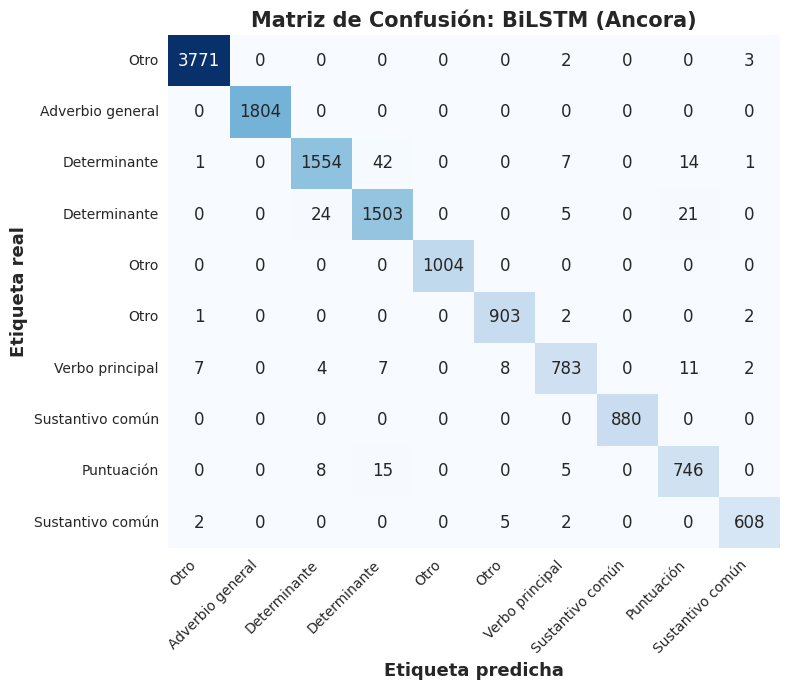

Matriz de confusión guardada como: confusion_bilstm_ancora.png


## Matriz de Confusión para BiLSTM-Deep entrenado con Ancora

Gráfica guardada en: /content/drive/My Drive/NPL/confusion_bilstmdeep_ancora.png


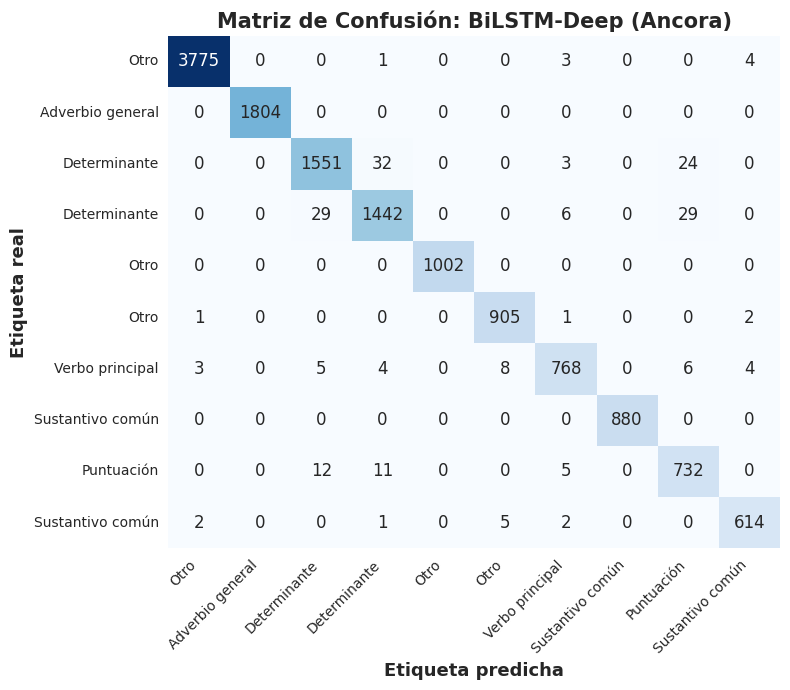

Matriz de confusión guardada como: confusion_bilstmdeep_ancora.png


## Matriz de Confusión para BiLSTM-CRF entrenado con Ancora

Gráfica guardada en: /content/drive/My Drive/NPL/confusion_bilstmcrf_ancora.png


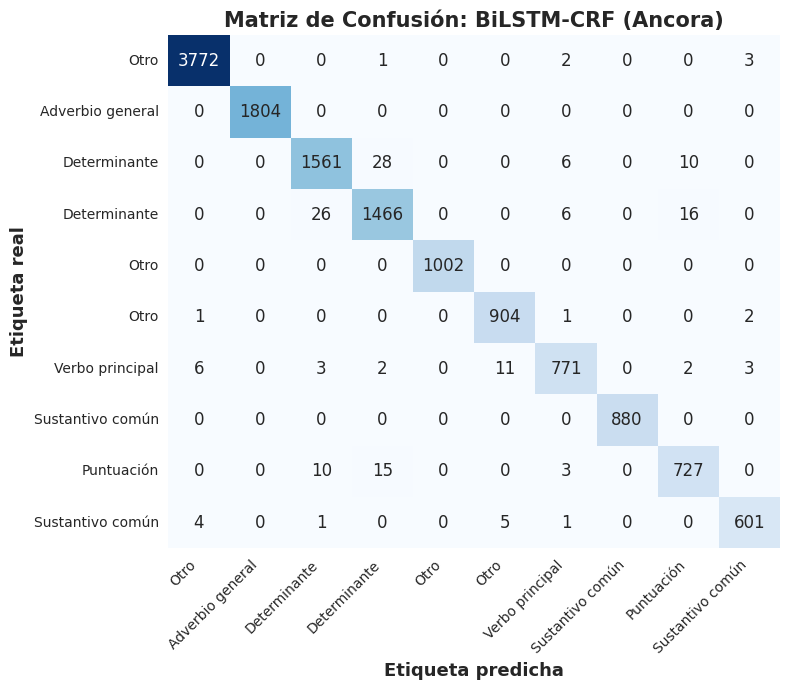

Matriz de confusión guardada como: confusion_bilstmcrf_ancora.png


## Matriz de Confusión para BiLSTM entrenado con CoNLL2002

Gráfica guardada en: /content/drive/My Drive/NPL/confusion_bilstm_conll.png


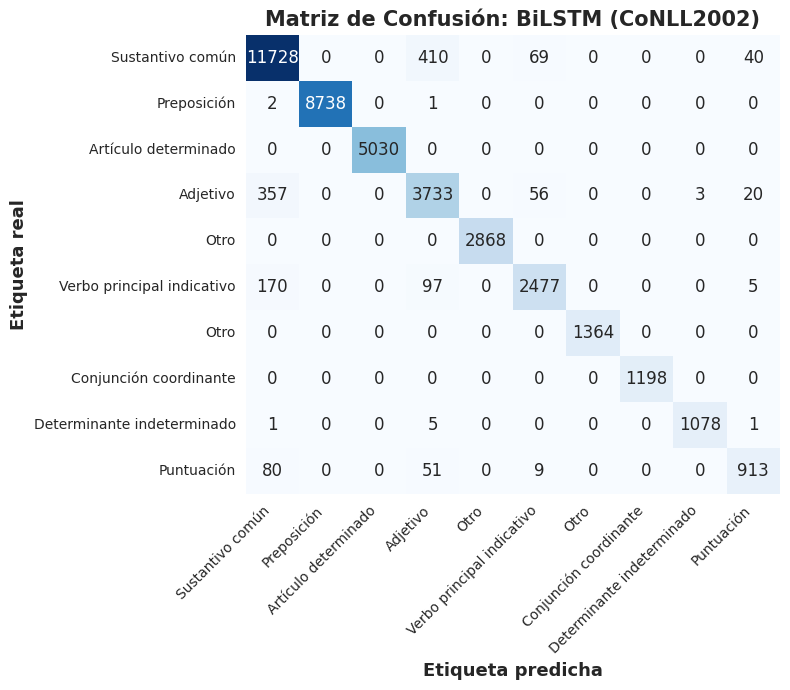

Matriz de confusión guardada como: confusion_bilstm_conll.png


## Matriz de Confusión para BiLSTM-Deep entrenado con CoNLL2002

Gráfica guardada en: /content/drive/My Drive/NPL/confusion_bilstmdeep_conll.png


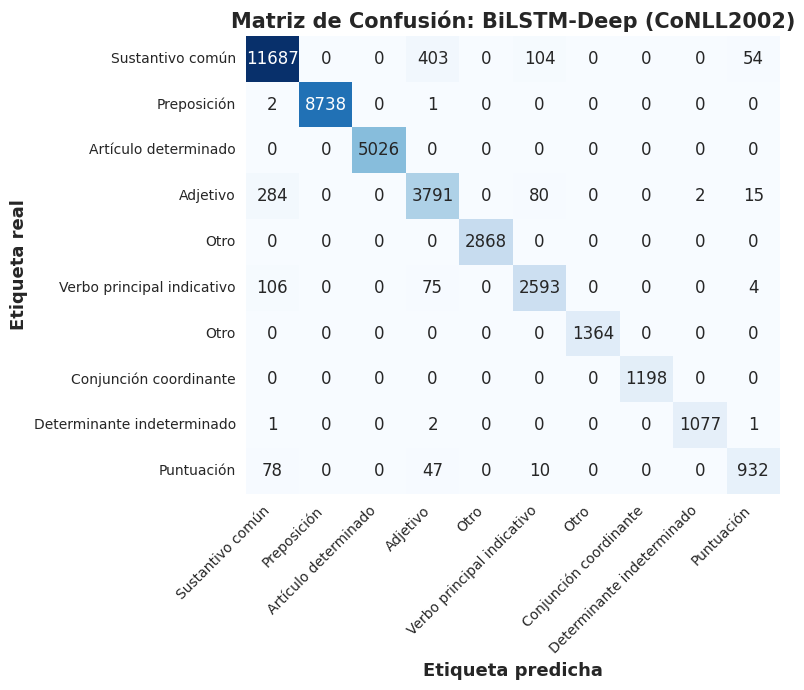

Matriz de confusión guardada como: confusion_bilstmdeep_conll.png


## Matriz de Confusión para BiLSTM-CRF entrenado con CoNLL2002

Gráfica guardada en: /content/drive/My Drive/NPL/confusion_bilstmcrf_conll.png


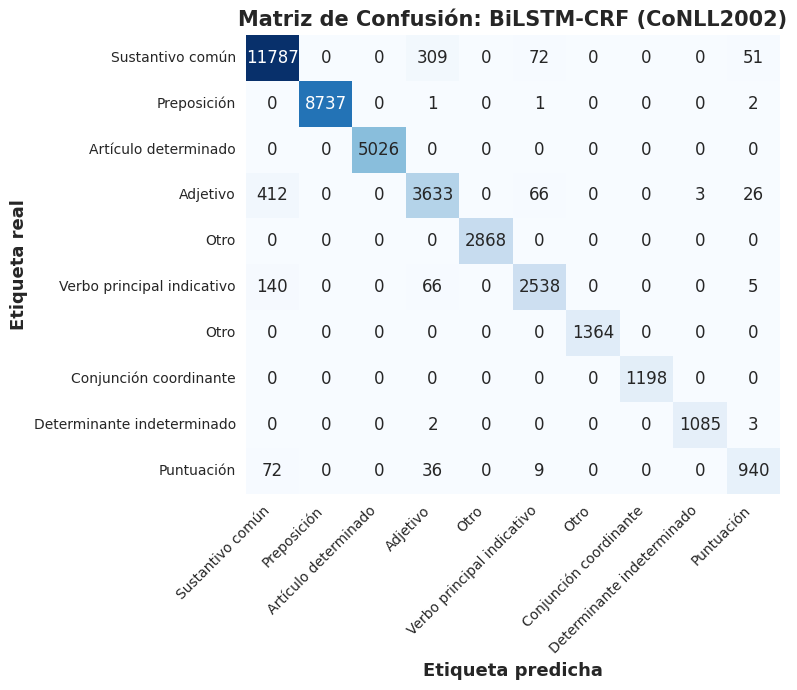

Matriz de confusión guardada como: confusion_bilstmcrf_conll.png


In [37]:
# Montar Google Drive si no está montado
definir_drive = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    definir_drive = True
except Exception:
    print("No se está ejecutando en Google Colab o Drive ya está montado.")

# Definir la ruta de la carpeta NPL en Drive
DRIVE_NPL_DIR = '/content/drive/My Drive/NPL/'
import os
if not os.path.exists(DRIVE_NPL_DIR):
    os.makedirs(DRIVE_NPL_DIR)

from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# --- FUNCIÓN PARA DESCRIPCIÓN DE ETIQUETAS ---
def obtener_descripcion_legible(tag):
    try:
        return obtener_descripcion_tag(tag)
    except Exception:
        return str(tag)

def savefig_npl(filename, **kwargs):
    """Guarda la figura en la carpeta NPL de Drive"""
    path = os.path.join(DRIVE_NPL_DIR, filename)
    plt.savefig(path, **kwargs)
    print(f"\033[1;32mGráfica guardada en: {path}\033[0m")

def print_section(title):
    display(Markdown(f"## {title}"))

def print_table(df, title=None):
    if title:
        display(Markdown(f"**{title}**"))
    # Reemplazar etiquetas por descripciones legibles si existe columna 'Tag'
    if 'Tag' in df.columns:
        df = df.copy()
        df['Tag'] = df['Tag'].apply(obtener_descripcion_legible)
    display(df.style.set_table_styles([
        {'selector': 'th', 'props': [('font-size', '12pt'), ('font-weight', 'bold'), ('background-color', '#f2f2f2')]},
        {'selector': 'td', 'props': [('font-size', '11pt')]}
    ]).set_properties(**{'text-align': 'center'}).hide_index())

def plot_simple_confusion(y_true, y_pred, labels, tag_names, title, filename, top_n=10):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    support = cm.sum(axis=1)
    top_idx = np.argsort(support)[-top_n:][::-1]
    cm_top = cm[top_idx][:, top_idx]
    tag_names_top = [tag_names[i] for i in top_idx]
    # Convertir a descripciones legibles
    tag_names_legibles = [obtener_descripcion_legible(t) for t in tag_names_top]
    plt.figure(figsize=(8,7))
    sns.heatmap(cm_top, annot=True, fmt='d', cmap='Blues', xticklabels=tag_names_legibles, yticklabels=tag_names_legibles, cbar=False, annot_kws={"size":12})
    plt.xlabel('Etiqueta predicha', fontsize=13, fontweight='bold')
    plt.ylabel('Etiqueta real', fontsize=13, fontweight='bold')
    plt.title(title, fontsize=15, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    savefig_npl(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\033[1;34mMatriz de confusión guardada como: {filename}\033[0m")

# Títulos descriptivos y claros para cada matriz
tag_names_ancora = [vocab_ancora.idx2tag[i] for i in range(len(vocab_ancora.idx2tag))]
print_section('Matriz de Confusión para BiLSTM entrenado con Ancora')
plot_simple_confusion(tags_b_a, preds_b_a, labels_b_a, tag_names_ancora, 'Matriz de Confusión: BiLSTM (Ancora)', 'confusion_bilstm_ancora.png')

print_section('Matriz de Confusión para BiLSTM-Deep entrenado con Ancora')
plot_simple_confusion(tags_bd_a, preds_bd_a, labels_bd_a, tag_names_ancora, 'Matriz de Confusión: BiLSTM-Deep (Ancora)', 'confusion_bilstmdeep_ancora.png')

print_section('Matriz de Confusión para BiLSTM-CRF entrenado con Ancora')
plot_simple_confusion(tags_bc_a, preds_bc_a, labels_bc_a, tag_names_ancora, 'Matriz de Confusión: BiLSTM-CRF (Ancora)', 'confusion_bilstmcrf_ancora.png')

if 'vocab_conll' in globals():
    tag_names_conll = [vocab_conll.idx2tag[i] for i in range(len(vocab_conll.idx2tag))]
    print_section('Matriz de Confusión para BiLSTM entrenado con CoNLL2002')
    plot_simple_confusion(tags_b_c, preds_b_c, labels_b_c, tag_names_conll, 'Matriz de Confusión: BiLSTM (CoNLL2002)', 'confusion_bilstm_conll.png')
    print_section('Matriz de Confusión para BiLSTM-Deep entrenado con CoNLL2002')
    plot_simple_confusion(tags_bd_c, preds_bd_c, labels_bd_c, tag_names_conll, 'Matriz de Confusión: BiLSTM-Deep (CoNLL2002)', 'confusion_bilstmdeep_conll.png')
    print_section('Matriz de Confusión para BiLSTM-CRF entrenado con CoNLL2002')
    plot_simple_confusion(tags_bc_c, preds_bc_c, labels_bc_c, tag_names_conll, 'Matriz de Confusión: BiLSTM-CRF (CoNLL2002)', 'confusion_bilstmcrf_conll.png')

# Para mostrar tablas ordenadas y legibles:
# print_table(df_resultados, title='Resultados de Métricas Globales')
# print_table(df_tags, title='Desempeño por Etiqueta')


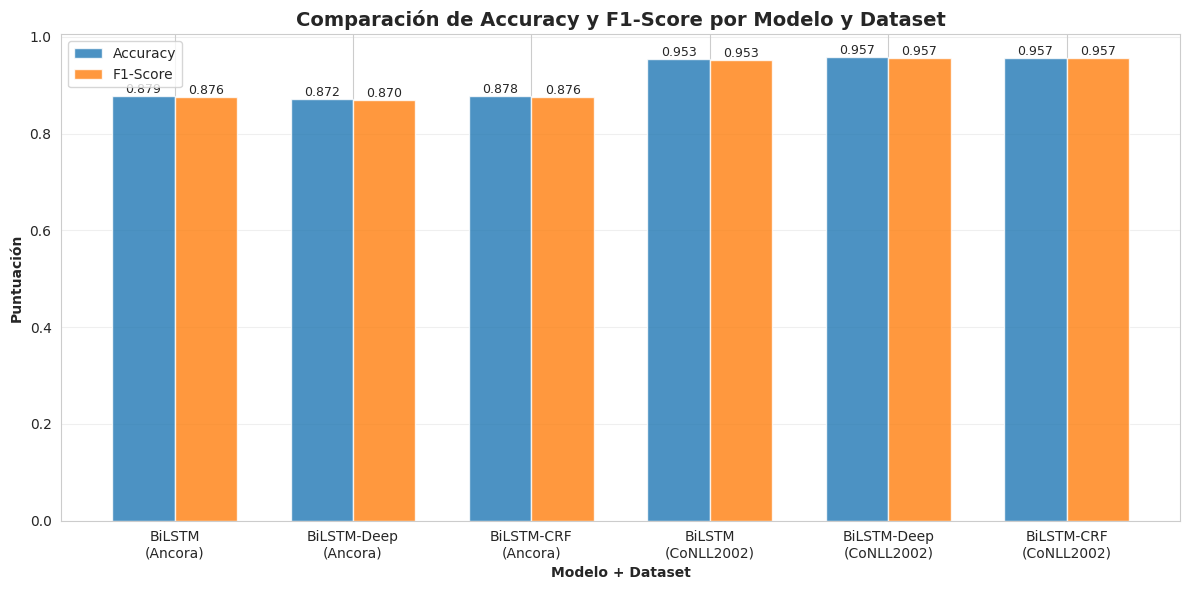

Gráfico de barras guardado como: comparacion_metricas.png


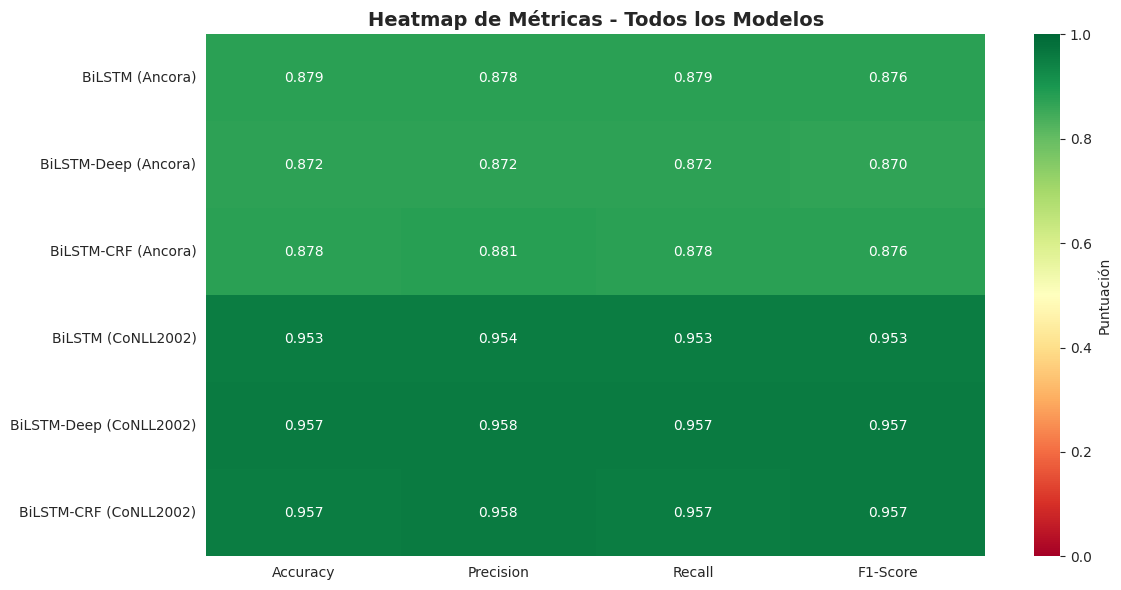

Heatmap guardado como: heatmap_resultados.png


In [38]:
# ========== GENERACIÓN DE GRÁFICOS DE COMPARACIÓN Y HEATMAP ==========

# Recopilar resultados en un DataFrame
resultados_finales = []

# Ancora
resultados_finales.append({
    'Modelo': 'BiLSTM',
    'Dataset': 'Ancora',
    'Accuracy': acc_b_a,
    'Precision': precision_score(tags_b_a, preds_b_a, average='weighted', zero_division=0),
    'Recall': recall_score(tags_b_a, preds_b_a, average='weighted', zero_division=0),
    'F1-Score': f1_score(tags_b_a, preds_b_a, average='weighted', zero_division=0)
})
resultados_finales.append({
    'Modelo': 'BiLSTM-Deep',
    'Dataset': 'Ancora',
    'Accuracy': acc_bd_a,
    'Precision': precision_score(tags_bd_a, preds_bd_a, average='weighted', zero_division=0),
    'Recall': recall_score(tags_bd_a, preds_bd_a, average='weighted', zero_division=0),
    'F1-Score': f1_score(tags_bd_a, preds_bd_a, average='weighted', zero_division=0)
})
resultados_finales.append({
    'Modelo': 'BiLSTM-CRF',
    'Dataset': 'Ancora',
    'Accuracy': acc_bc_a,
    'Precision': precision_score(tags_bc_a, preds_bc_a, average='weighted', zero_division=0),
    'Recall': recall_score(tags_bc_a, preds_bc_a, average='weighted', zero_division=0),
    'F1-Score': f1_score(tags_bc_a, preds_bc_a, average='weighted', zero_division=0)
})

# CoNLL2002
resultados_finales.append({
    'Modelo': 'BiLSTM',
    'Dataset': 'CoNLL2002',
    'Accuracy': acc_b_c,
    'Precision': precision_score(tags_b_c, preds_b_c, average='weighted', zero_division=0),
    'Recall': recall_score(tags_b_c, preds_b_c, average='weighted', zero_division=0),
    'F1-Score': f1_score(tags_b_c, preds_b_c, average='weighted', zero_division=0)
})
resultados_finales.append({
    'Modelo': 'BiLSTM-Deep',
    'Dataset': 'CoNLL2002',
    'Accuracy': acc_bd_c,
    'Precision': precision_score(tags_bd_c, preds_bd_c, average='weighted', zero_division=0),
    'Recall': recall_score(tags_bd_c, preds_bd_c, average='weighted', zero_division=0),
    'F1-Score': f1_score(tags_bd_c, preds_bd_c, average='weighted', zero_division=0)
})
resultados_finales.append({
    'Modelo': 'BiLSTM-CRF',
    'Dataset': 'CoNLL2002',
    'Accuracy': acc_bc_c,
    'Precision': precision_score(tags_bc_c, preds_bc_c, average='weighted', zero_division=0),
    'Recall': recall_score(tags_bc_c, preds_bc_c, average='weighted', zero_division=0),
    'F1-Score': f1_score(tags_bc_c, preds_bc_c, average='weighted', zero_division=0)
})

results_table = pd.DataFrame(resultados_finales)


# ========== GRÁFICO DE COMPARACIÓN DE ACCURACY Y F1-SCORE ==========
fig1, ax1 = plt.subplots(figsize=(12, 6))

modelos = results_table['Modelo'].values
datasets = results_table['Dataset'].values
labels = [f"{mod}\n({dat})" for mod, dat in zip(modelos, datasets)]
accuracies = results_table['Accuracy'].values
f1_scores = results_table['F1-Score'].values

x = np.arange(len(labels))
width = 0.35

bars1 = ax1.bar(x - width/2, accuracies, width, label='Accuracy', alpha=0.8)
bars2 = ax1.bar(x + width/2, f1_scores, width, label='F1-Score', alpha=0.8)

ax1.set_xlabel('Modelo + Dataset', fontweight='bold')
ax1.set_ylabel('Puntuación', fontweight='bold')
ax1.set_title('Comparación de Accuracy y F1-Score por Modelo y Dataset', fontweight='bold', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico de barras guardado como: comparacion_metricas.png")


# ========== HEATMAP DE RESULTADOS ==========
fig2, ax2 = plt.subplots(figsize=(12, 6))

# Crear matriz para heatmap
heatmap_data = results_table[['Accuracy', 'Precision', 'Recall', 'F1-Score']].values
heatmap_labels = results_table['Modelo'].values + ' (' + results_table['Dataset'].values + ')'

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
            yticklabels=heatmap_labels,
            cbar_kws={'label': 'Puntuación'}, ax=ax2)

ax2.set_title('Heatmap de Métricas - Todos los Modelos', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

print("Heatmap guardado como: heatmap_resultados.png")

In [39]:
# ========== ANÁLISIS COMPARATIVO DE MODELOS ==========

print("\n" + "="*90)
print("ANÁLISIS COMPARATIVO DEL DESEMPEÑO DE MODELOS")
print("="*90)

# Organizar resultados por dataset
results_ancora = results_table[results_table['Dataset'] == 'Ancora'].copy()
results_conll = results_table[results_table['Dataset'] == 'CoNLL2002'].copy()

print("\n" + "-"*90)
print("DATASET ANCORA")
print("-"*90)

print("\nRanking por Accuracy:")
ranking_acc_a = results_ancora.sort_values('Accuracy', ascending=False)[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
print(ranking_acc_a.to_string(index=False))

print(f"\nMejor modelo en Ancora: {results_ancora.loc[results_ancora['Accuracy'].idxmax(), 'Modelo']}")
print(f"Accuracy: {results_ancora['Accuracy'].max():.4f}")
print(f"F1-Score: {results_ancora.loc[results_ancora['Accuracy'].idxmax(), 'F1-Score']:.4f}")

print("\n" + "-"*90)
print("DATASET CONLL2002")
print("-"*90)

print("\nRanking por Accuracy:")
ranking_acc_c = results_conll.sort_values('Accuracy', ascending=False)[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
print(ranking_acc_c.to_string(index=False))

print(f"\nMejor modelo en CoNLL2002: {results_conll.loc[results_conll['Accuracy'].idxmax(), 'Modelo']}")
print(f"Accuracy: {results_conll['Accuracy'].max():.4f}")
print(f"F1-Score: {results_conll.loc[results_conll['Accuracy'].idxmax(), 'F1-Score']:.4f}")

# Análisis de arquitectura
print("\n" + "-"*90)
print("ANÁLISIS POR ARQUITECTURA")
print("-"*90)

arch_analysis = results_table.groupby('Modelo')[['Accuracy', 'F1-Score']].mean()
print("\nDesempeño promedio por arquitectura (ambos datasets):")
print(arch_analysis.to_string())

print("\nObservaciones:")
print("- BiLSTM Base: Arquitectura simple, línea base para comparación")
print("- BiLSTM-Deep: Añade complejidad no lineal mediante capas densas intermedias")
print("- BiLSTM-CRF: Modela dependencias secuenciales entre etiquetas")

# Diferencias de desempeño
diff_deep_vs_base = results_table[results_table['Modelo'] == 'BiLSTM-Deep']['F1-Score'].mean() - results_table[results_table['Modelo'] == 'BiLSTM']['F1-Score'].mean()
diff_crf_vs_base = results_table[results_table['Modelo'] == 'BiLSTM-CRF']['F1-Score'].mean() - results_table[results_table['Modelo'] == 'BiLSTM']['F1-Score'].mean()

print(f"\nDiferencia F1-Score (BiLSTM-Deep vs BiLSTM): {diff_deep_vs_base:+.4f}")
print(f"Diferencia F1-Score (BiLSTM-CRF vs BiLSTM): {diff_crf_vs_base:+.4f}")

# Análisis por dataset
print("\n" + "-"*90)
print("ANÁLISIS POR DATASET")
print("-"*90)

dataset_analysis = results_table.groupby('Dataset')[['Accuracy', 'F1-Score']].mean()
print("\nDesempeño promedio por dataset (todos los modelos):")
print(dataset_analysis.to_string())

diff_datasets = results_table[results_table['Dataset'] == 'Ancora']['Accuracy'].mean() - results_table[results_table['Dataset'] == 'CoNLL2002']['Accuracy'].mean()
print(f"\nDiferencia de Accuracy (Ancora vs CoNLL2002): {diff_datasets:+.4f}")

if abs(diff_datasets) > 0.05:
    if diff_datasets > 0:
        print("Interpretacion: Ancora es un dataset mas accesible que CoNLL2002")
    else:
        print("Interpretacion: CoNLL2002 es un dataset mas accesible que Ancora")



ANÁLISIS COMPARATIVO DEL DESEMPEÑO DE MODELOS

------------------------------------------------------------------------------------------
DATASET ANCORA
------------------------------------------------------------------------------------------

Ranking por Accuracy:
     Modelo  Accuracy  Precision   Recall  F1-Score
     BiLSTM  0.878620   0.878399 0.878620  0.875735
 BiLSTM-CRF  0.878304   0.880872 0.878304  0.875755
BiLSTM-Deep  0.871994   0.872076 0.871994  0.869683

Mejor modelo en Ancora: BiLSTM
Accuracy: 0.8786
F1-Score: 0.8757

------------------------------------------------------------------------------------------
DATASET CONLL2002
------------------------------------------------------------------------------------------

Ranking por Accuracy:
     Modelo  Accuracy  Precision   Recall  F1-Score
BiLSTM-Deep  0.957378   0.958336 0.957378  0.957127
 BiLSTM-CRF  0.956910   0.957866 0.956910  0.957114
     BiLSTM  0.953280   0.954087 0.953280  0.953194

Mejor modelo en CoNLL2002


MATRICES DE CONFUSIÓN - ANÁLISIS DE ERRORES (Mejoradas)


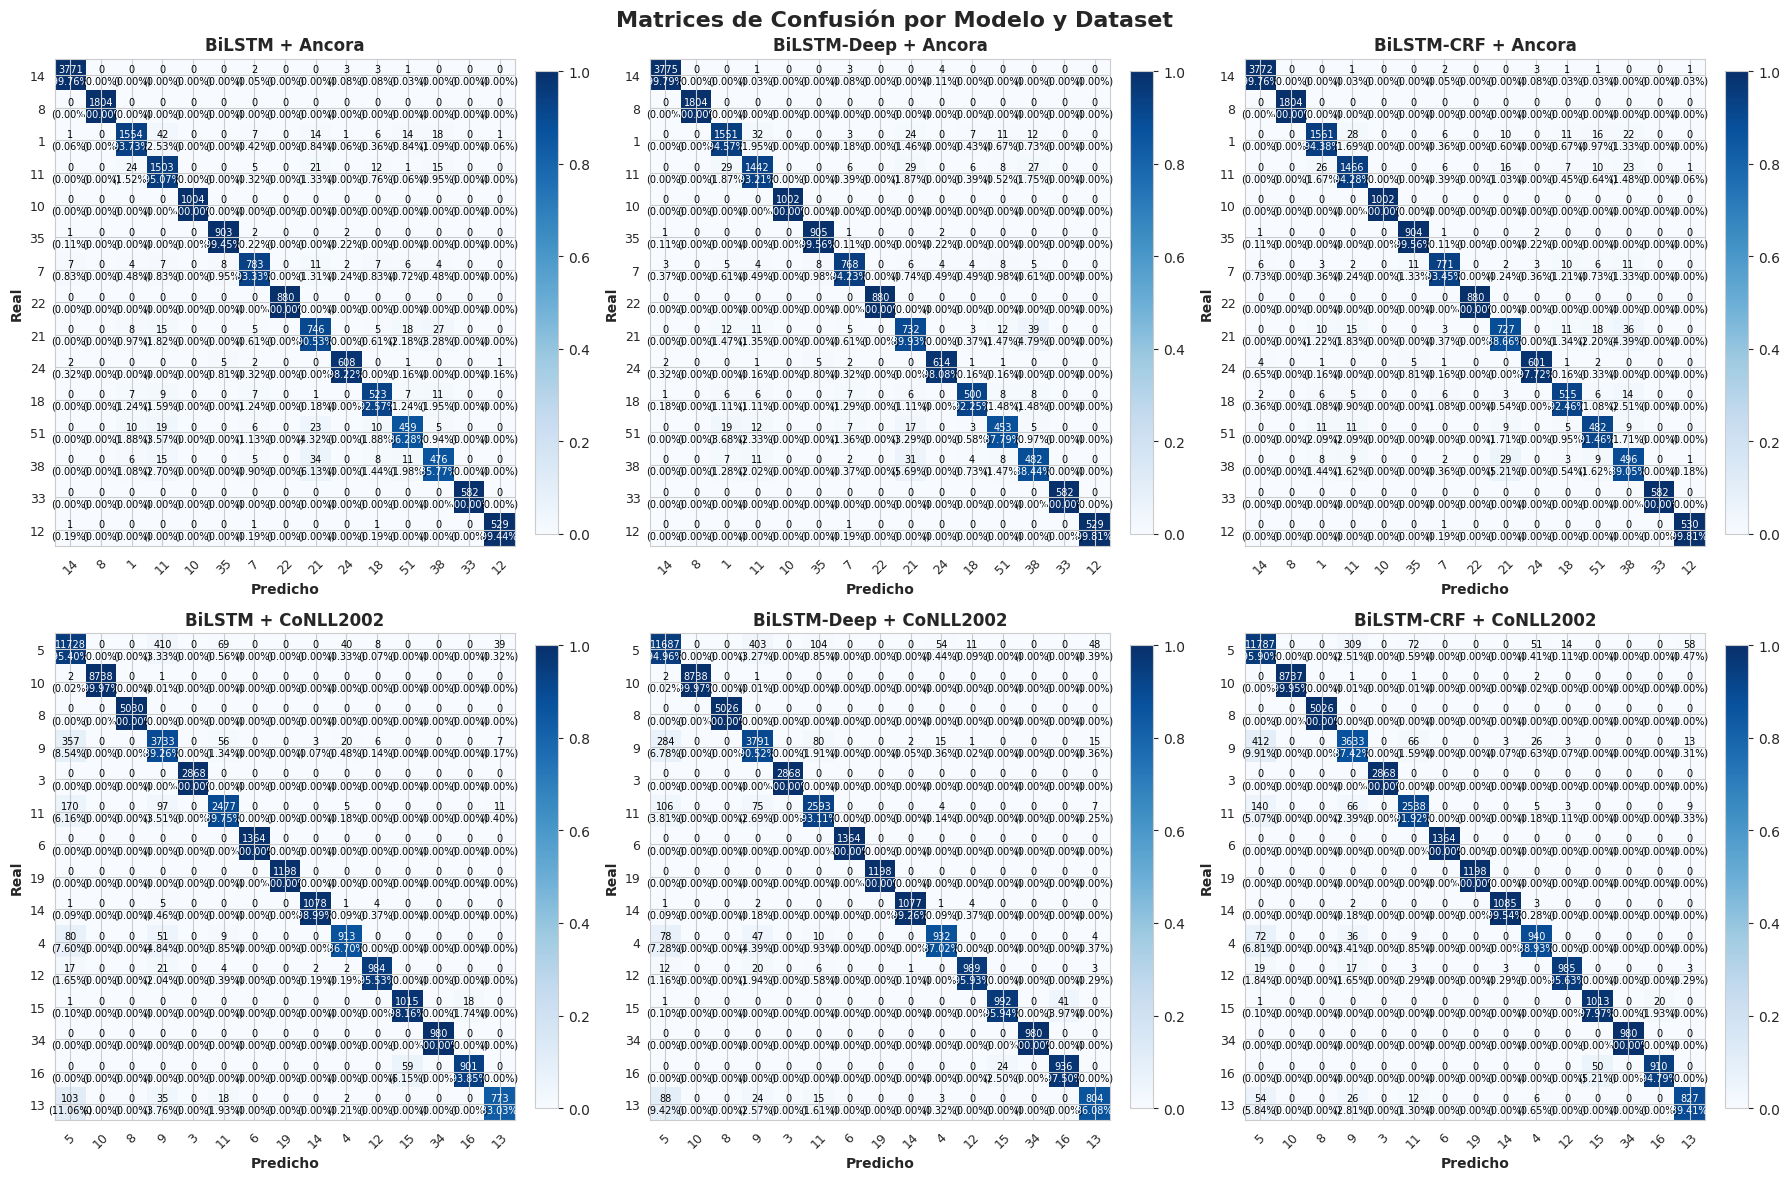


Matrices de confusión mejoradas guardadas como: matrices_confusion_mejoradas.png

Análisis de errores más frecuentes (Ancora BiLSTM):

Top 5 errores de confusión más frecuentes:
  60 veces: 'pr0fs000' fue confundido como 'vsip3s0'
  48 veces: 'nccs000' fue confundido como 'aq0msp'
  46 veces: 'vmip1s0' fue confundido como 'dp3cs0'
  42 veces: 'da0ms0' fue confundido como 'da0fs0'
  35 veces: 'vsip3s0' fue confundido como 'da0fs0'

Análisis de errores más frecuentes (CoNLL2002 BiLSTM):

Top 5 errores de confusión más frecuentes:
  410 veces: 'NC' fue confundido como 'AQ'
  357 veces: 'AQ' fue confundido como 'NC'
  170 veces: 'VMI' fue confundido como 'NC'
  103 veces: 'VMN' fue confundido como 'NC'
  97 veces: 'VMI' fue confundido como 'AQ'


In [40]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ========== MATRICES DE CONFUSIÓN MEJORADAS ==========
print("\n" + "="*90)
print("MATRICES DE CONFUSIÓN - ANÁLISIS DE ERRORES (Mejoradas)")
print("="*90)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Matrices de Confusión por Modelo y Dataset', fontsize=16, fontweight='bold')

# Función auxiliar para plotear matriz de confusión mejorada
def plot_confusion_matrix(ax, y_true, y_pred, labels, title, max_labels=15):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Mostrar solo las etiquetas más frecuentes si hay muchas
    if len(labels) > max_labels:
        # Seleccionar las etiquetas con más soporte
        support = cm.sum(axis=1)
        top_idx = np.argsort(support)[-max_labels:][::-1]
        cm = cm[top_idx][:, top_idx]
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        labels_plot = [str(labels[i])[:6] for i in top_idx]
    else:
        labels_plot = [str(l)[:6] for l in labels]

    im = ax.imshow(cm_percent, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(labels_plot)))
    ax.set_yticks(range(len(labels_plot)))
    ax.set_xticklabels(labels_plot, rotation=45, fontsize=9)
    ax.set_yticklabels(labels_plot, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicho', fontweight='bold')
    ax.set_ylabel('Real', fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # Anotar porcentajes y valores absolutos
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            percent = cm_percent[i, j]
            ax.text(j, i, f'{value}\n({percent:.2%})', ha='center', va='center', fontsize=7, color='black' if percent < 0.5 else 'white')

# Ancora
plot_confusion_matrix(axes[0, 0], tags_b_a, preds_b_a, labels_b_a, 'BiLSTM + Ancora')
plot_confusion_matrix(axes[0, 1], tags_bd_a, preds_bd_a, labels_bd_a, 'BiLSTM-Deep + Ancora')
plot_confusion_matrix(axes[0, 2], tags_bc_a, preds_bc_a, labels_bc_a, 'BiLSTM-CRF + Ancora')

# CoNLL2002
plot_confusion_matrix(axes[1, 0], tags_b_c, preds_b_c, labels_b_c, 'BiLSTM + CoNLL2002')
plot_confusion_matrix(axes[1, 1], tags_bd_c, preds_bd_c, labels_bd_c, 'BiLSTM-Deep + CoNLL2002')
plot_confusion_matrix(axes[1, 2], tags_bc_c, preds_bc_c, labels_bc_c, 'BiLSTM-CRF + CoNLL2002')

plt.tight_layout()
plt.savefig('matrices_confusion_mejoradas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMatrices de confusión mejoradas guardadas como: matrices_confusion_mejoradas.png")

# ========== ANÁLISIS AUTOMÁTICO DE ERRORES MÁS FRECUENTES ==========
def analizar_errores_frecuentes(y_true, y_pred, vocab, top_n=5):
    cm = confusion_matrix(y_true, y_pred)
    etiquetas = [vocab.idx2tag.get(i, str(i)) for i in range(cm.shape[0])]
    errores = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                errores.append((cm[i, j], etiquetas[i], etiquetas[j]))
    errores.sort(reverse=True)
    print(f"\nTop {top_n} errores de confusión más frecuentes:")
    for count, real, pred in errores[:top_n]:
        print(f"  {count} veces: '{real}' fue confundido como '{pred}'")

print("\nAnálisis de errores más frecuentes (Ancora BiLSTM):")
analizar_errores_frecuentes(tags_b_a, preds_b_a, vocab_ancora)
print("\nAnálisis de errores más frecuentes (CoNLL2002 BiLSTM):")
analizar_errores_frecuentes(tags_b_c, preds_b_c, vocab_conll)


In [41]:
# ========== ANÁLISIS DE DESEMPEÑO POR ETIQUETA ==========
print("\n" + "="*90)
print("ANÁLISIS DE DESEMPEÑO POR ETIQUETA")
print("="*90)

from sklearn.metrics import precision_recall_fscore_support

def analizar_tags(y_true, y_pred, vocab, dataset_name, modelo_name):
    """Analiza el desempeño por etiqueta individual"""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )

    resultados_por_tag = []
    for idx in range(len(precision)):
        if support[idx] > 0:  # Solo etiquetas presentes
            tag_name = vocab.idx2tag.get(idx, f"Tag_{idx}")
            resultados_por_tag.append({
                'Tag': tag_name,
                'Precision': precision[idx],
                'Recall': recall[idx],
                'F1-Score': f1[idx],
                'Support': int(support[idx])
            })

    df_tags = pd.DataFrame(resultados_por_tag)
    df_tags = df_tags.sort_values('F1-Score', ascending=False)

    return df_tags

print("\nETIQUETAS CON MEJOR DESEMPEÑO (BiLSTM Base - Ancora):")
df_best_tags_a = analizar_tags(tags_b_a, preds_b_a, vocab_ancora, 'Ancora', 'BiLSTM')
print("\nTop 5 Tags con mejor F1-Score:")
print(df_best_tags_a.head(5).to_string(index=False))

print("\n\nETIQUETAS CON PEOR DESEMPEÑO (BiLSTM Base - Ancora):")
print("\nTop 5 Tags con peor F1-Score:")
print(df_best_tags_a.tail(5).to_string(index=False))

print("\n\nETIQUETAS CON MEJOR DESEMPEÑO (BiLSTM Base - CoNLL2002):")
df_best_tags_c = analizar_tags(tags_b_c, preds_b_c, vocab_conll, 'CoNLL2002', 'BiLSTM')
print("\nTop 5 Tags con mejor F1-Score:")
print(df_best_tags_c.head(5).to_string(index=False))

print("\n\nETIQUETAS CON PEOR DESEMPEÑO (BiLSTM Base - CoNLL2002):")
print("\nTop 5 Tags con peor F1-Score:")
print(df_best_tags_c.tail(5).to_string(index=False))

# Análisis de dificultad
print("\n" + "-"*90)
print("ANÁLISIS DE DIFICULTAD DE ETIQUETAS")
print("-"*90)

print("\nEtiquetas faciles (F1 > 0.85):")
easy_tags_a = df_best_tags_a[df_best_tags_a['F1-Score'] > 0.85][['Tag', 'F1-Score', 'Support']]
if len(easy_tags_a) > 0:
    print(f"Ancora: {len(easy_tags_a)} etiquetas")
    print(easy_tags_a.to_string(index=False))

easy_tags_c = df_best_tags_c[df_best_tags_c['F1-Score'] > 0.85][['Tag', 'F1-Score', 'Support']]
if len(easy_tags_c) > 0:
    print(f"\nCoNLL2002: {len(easy_tags_c)} etiquetas")
    print(easy_tags_c.to_string(index=False))

print("\n\nEtiquetas dificiles (F1 < 0.70):")
hard_tags_a = df_best_tags_a[df_best_tags_a['F1-Score'] < 0.70][['Tag', 'F1-Score', 'Support']]
if len(hard_tags_a) > 0:
    print(f"Ancora: {len(hard_tags_a)} etiquetas")
    print(hard_tags_a.to_string(index=False))

hard_tags_c = df_best_tags_c[df_best_tags_c['F1-Score'] < 0.70][['Tag', 'F1-Score', 'Support']]
if len(hard_tags_c) > 0:
    print(f"\nCoNLL2002: {len(hard_tags_c)} etiquetas")
    print(hard_tags_c.to_string(index=False))



ANÁLISIS DE DESEMPEÑO POR ETIQUETA

ETIQUETAS CON MEJOR DESEMPEÑO (BiLSTM Base - Ancora):

Top 5 Tags con mejor F1-Score:
     Tag  Precision  Recall  F1-Score  Support
 np00000        1.0     1.0       1.0      160
     Fpa        1.0     1.0       1.0      162
 ncmp000        1.0     1.0       1.0      880
pt0ms000        1.0     1.0       1.0      195
  ao0fs0        1.0     1.0       1.0      132


ETIQUETAS CON PEOR DESEMPEÑO (BiLSTM Base - Ancora):

Top 5 Tags con peor F1-Score:
    Tag  Precision  Recall  F1-Score  Support
vasi1s0        0.0     0.0       0.0        2
vsii1s0        0.0     0.0       0.0        1
      i        0.0     0.0       0.0        1
    Faa        0.0     0.0       0.0        1
    Fat        0.0     0.0       0.0        2


ETIQUETAS CON MEJOR DESEMPEÑO (BiLSTM Base - CoNLL2002):

Top 5 Tags con mejor F1-Score:
Tag  Precision  Recall  F1-Score  Support
Fpa        1.0     1.0       1.0      454
Fpt        1.0     1.0       1.0      455
 Fc        1.0  

In [42]:
# --- FILTRAR ETIQUETAS VÁLIDAS EN MATRIZ DE CONFUSIÓN ---

# Define aquí las etiquetas válidas que quieres mostrar (puedes personalizar esta lista)

etiquetas_validas = [
    # Ejemplo: 'NOUN', 'VERB', 'ADJ', ...
    # Agrega aquí las etiquetas que realmente te interesan
]


# Si etiquetas_validas está vacía, se mostrarán todas las etiquetas

def plot_confusion_filtrada(y_true, y_pred, labels, tag_names, title, filename, etiquetas_validas=None, top_n=10):
    if etiquetas_validas:
        # Filtra solo las etiquetas válidas
        indices_validos = [i for i, tag in enumerate(tag_names) if tag in etiquetas_validas]
        if not indices_validos:
            print('No hay coincidencias entre etiquetas válidas y las etiquetas del modelo.')
            return
        labels = [labels[i] for i in indices_validos]
        tag_names = [tag_names[i] for i in indices_validos]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    support = cm.sum(axis=1)
    top_idx = np.argsort(support)[-top_n:][::-1] if not etiquetas_validas else range(len(labels))
    cm_top = cm[top_idx][:, top_idx]
    tag_names_top = [tag_names[i] for i in top_idx]
    tag_names_legibles = [obtener_descripcion_legible(t) for t in tag_names_top]
    plt.figure(figsize=(8,7))
    sns.heatmap(cm_top, annot=True, fmt='d', cmap='Blues', xticklabels=tag_names_legibles, yticklabels=tag_names_legibles, cbar=False, annot_kws={"size":12})
    plt.xlabel('Etiqueta predicha', fontsize=13, fontweight='bold')
    plt.ylabel('Etiqueta real', fontsize=13, fontweight='bold')
    plt.title(title, fontsize=15, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    savefig_npl(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\033[1;34mMatriz de confusión guardada como: {filename}\033[0m")


# Ejemplo de uso:
# plot_confusion_filtrada(tags_b_a, preds_b_a, labels_b_a, tag_names_ancora, 'Matriz de Confusión Filtrada', 'confusion_filtrada.png', etiquetas_validas=etiquetas_validas)
